# Hands On: DBSCAN

## Objetivos

- Compreender a clusterização baseada em densidade
- Aplicar o algoritmo DBSCAN
- Explorar os parâmetros eps e min_samples
- Visualizar os clusters encontrados
- Identificar outliers automaticamente
- Comparar os resultados com métodos particionais

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')

## Carregando o Dataset

Utilizaremos o conjunto de dados Iris para facilitar a comparação com K-Means e K-Medoids.

In [ ]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
X.head()

In [ ]:
print(f'Número de observações: {X.shape[0]}')
print(f'Número de atributos: {X.shape[1]}')

## Normalização dos Dados

O DBSCAN depende de medidas de distância. Portanto, é recomendado normalizar os atributos antes da execução do algoritmo.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Conceitos Fundamentais

- eps: raio da vizinhança
- min_samples: número mínimo de vizinhos para formar uma região densa
- Pontos isolados são classificados como ruído (outliers)

## Aplicando DBSCAN

In [ ]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)
np.unique(labels_dbscan)

## Quantidade de Clusters Encontrados

In [ ]:
n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_outliers = list(labels_dbscan).count(-1)
print(f'Clusters encontrados: {n_clusters}')
print(f'Outliers identificados: {n_outliers}')

## Redução de Dimensionalidade com PCA

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)

## Visualização dos Clusters

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_dbscan, cmap='viridis')
plt.title('Clusters Encontrados pelo DBSCAN')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

## Visualização dos Outliers

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[labels_dbscan != -1,0], X_pca[labels_dbscan != -1,1], c=labels_dbscan[labels_dbscan != -1], cmap='viridis', label='Clusters')
plt.scatter(X_pca[labels_dbscan == -1,0], X_pca[labels_dbscan == -1,1], c='red', marker='x', s=120, label='Outliers')
plt.legend()
plt.title('DBSCAN - Detecção de Outliers')
plt.show()

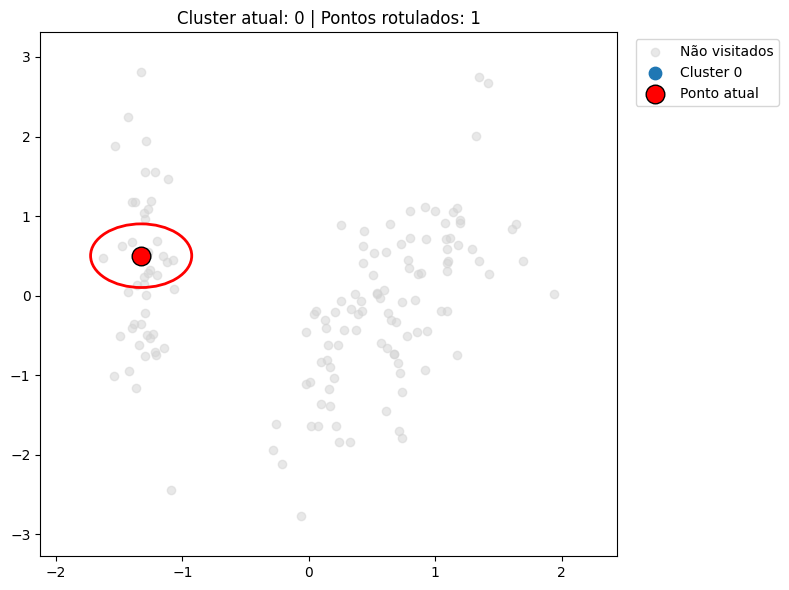

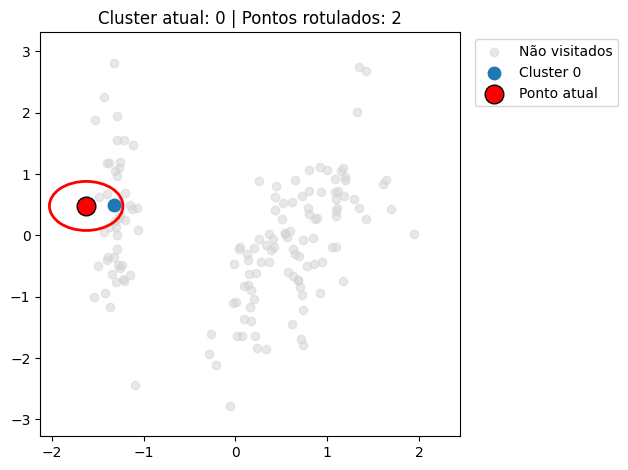

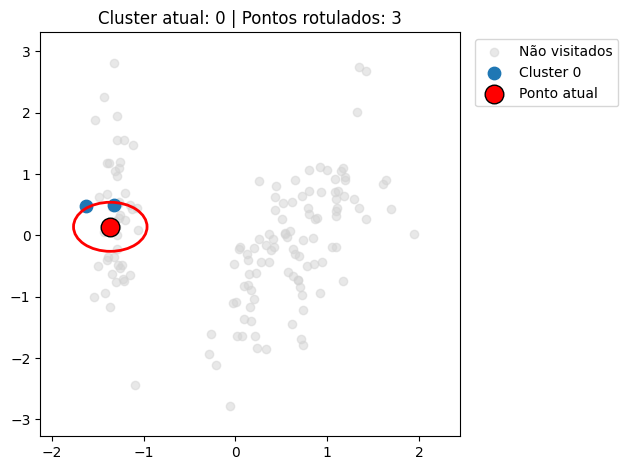

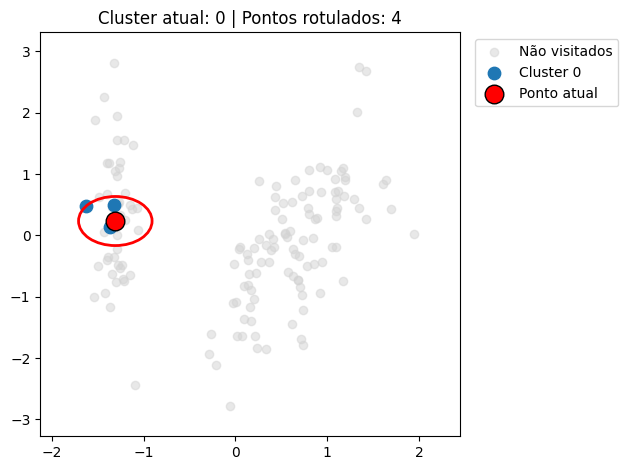

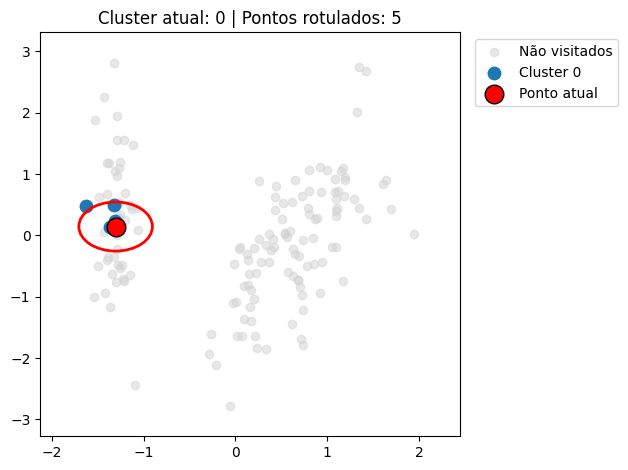

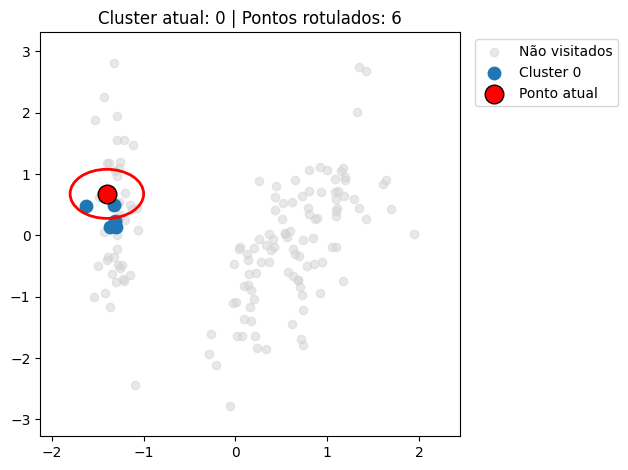

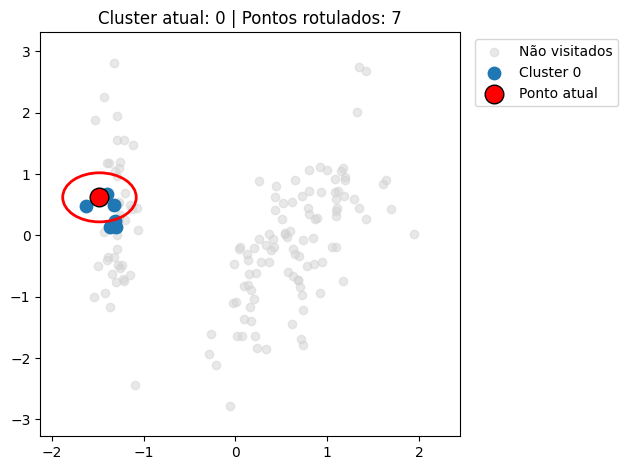

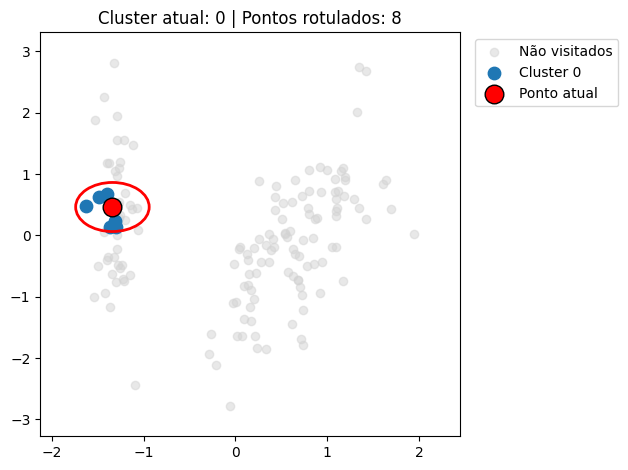

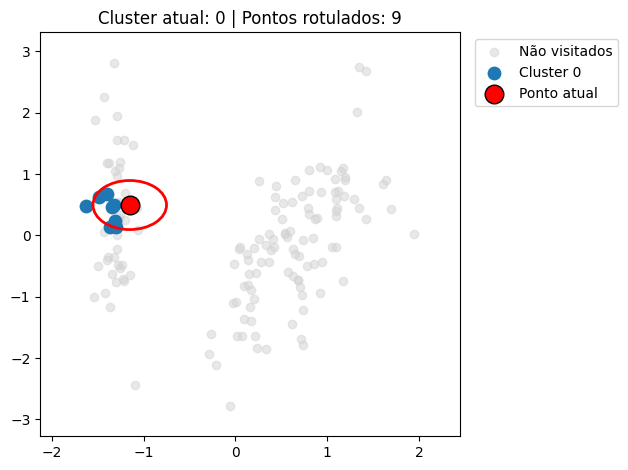

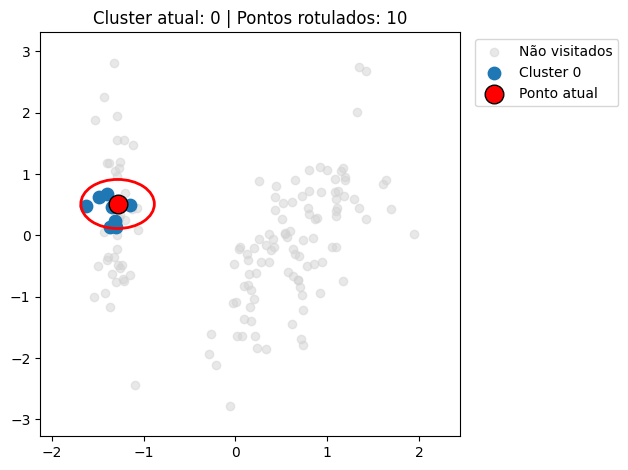

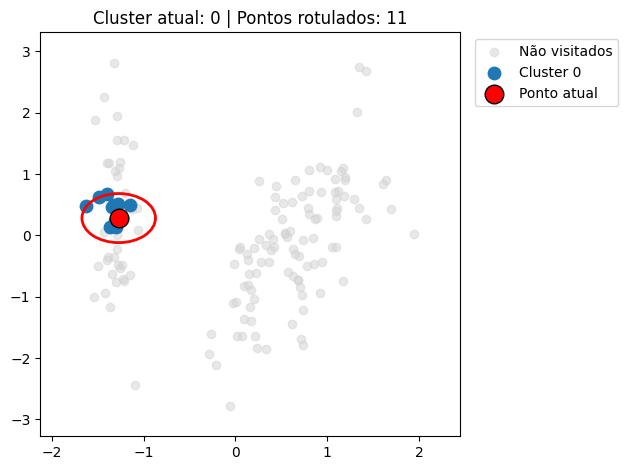

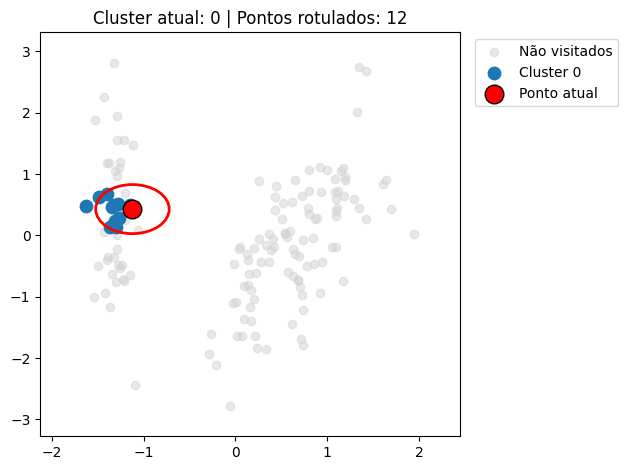

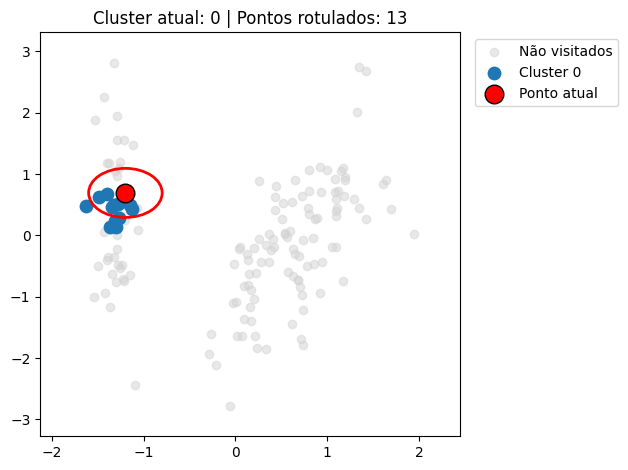

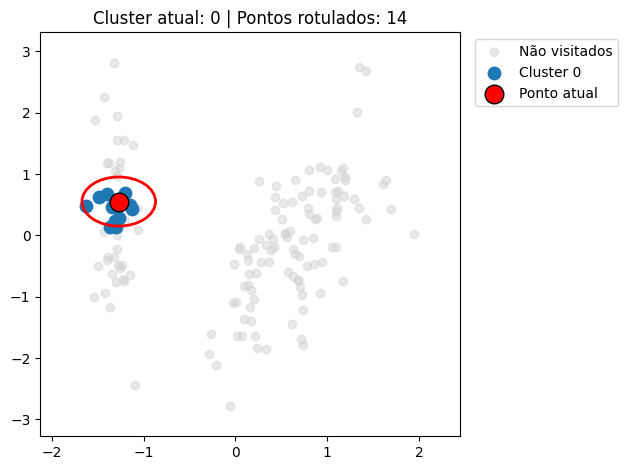

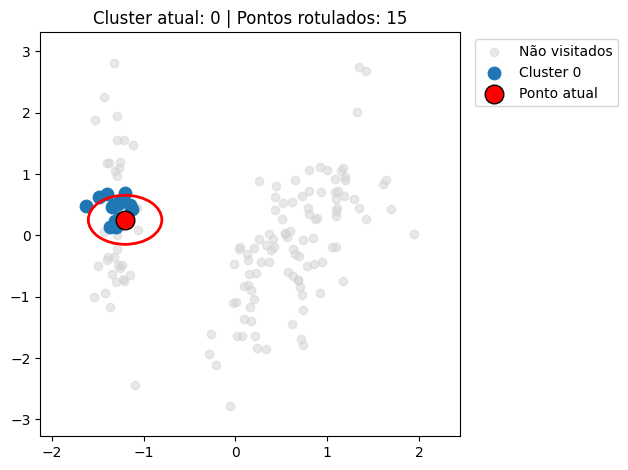

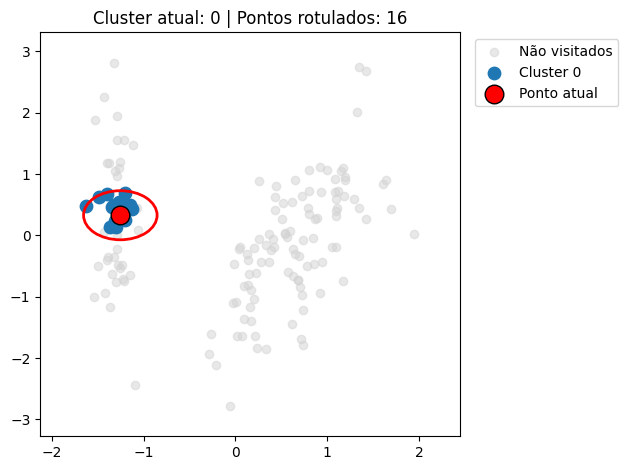

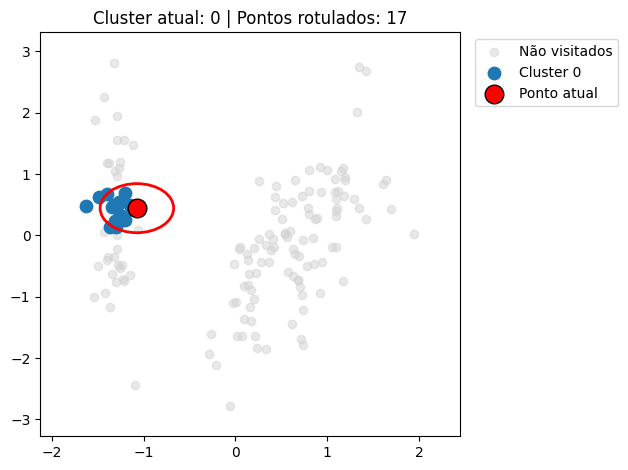

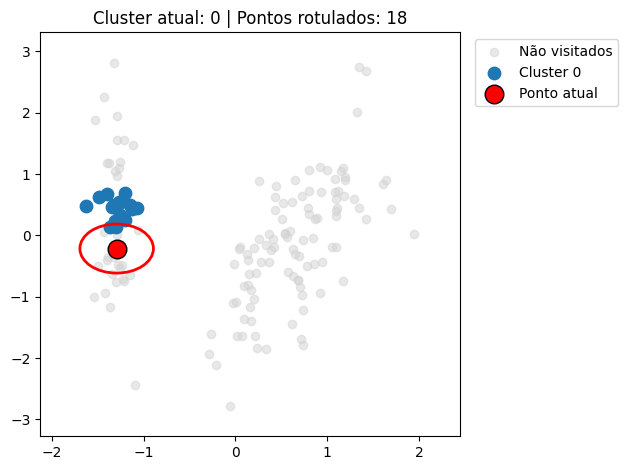

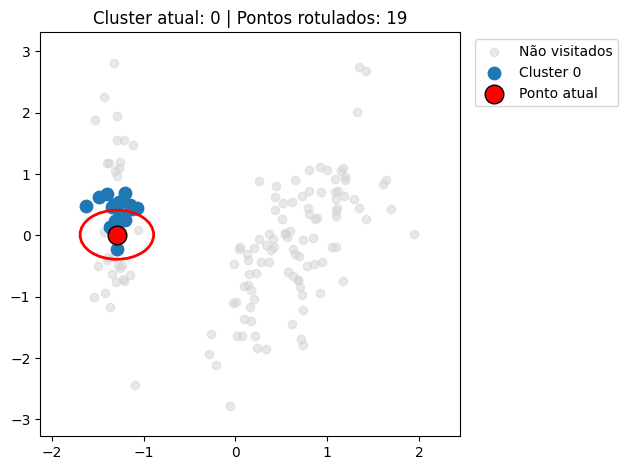

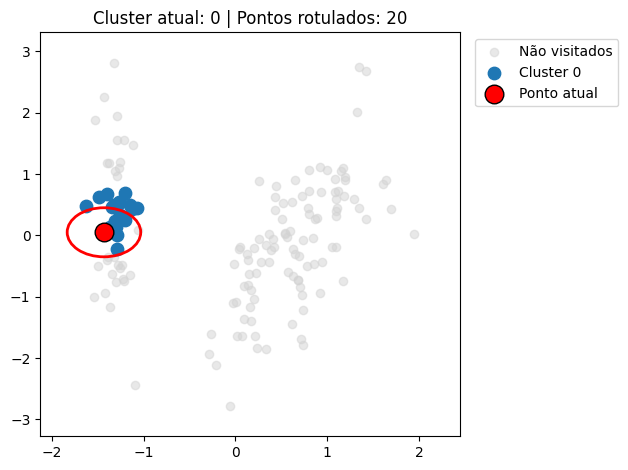

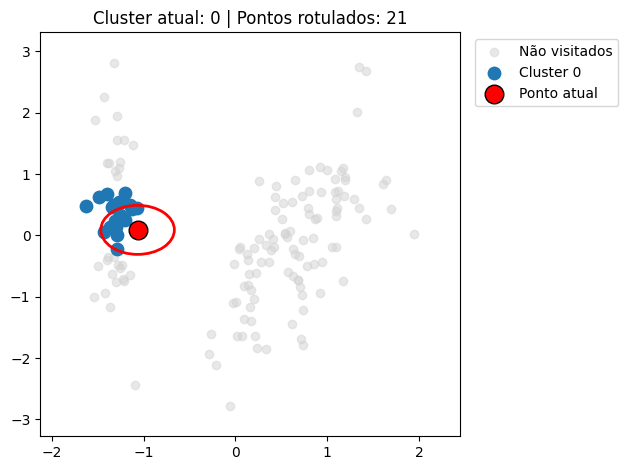

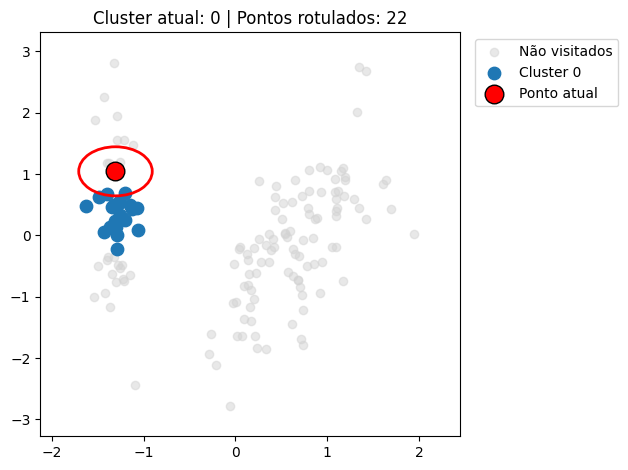

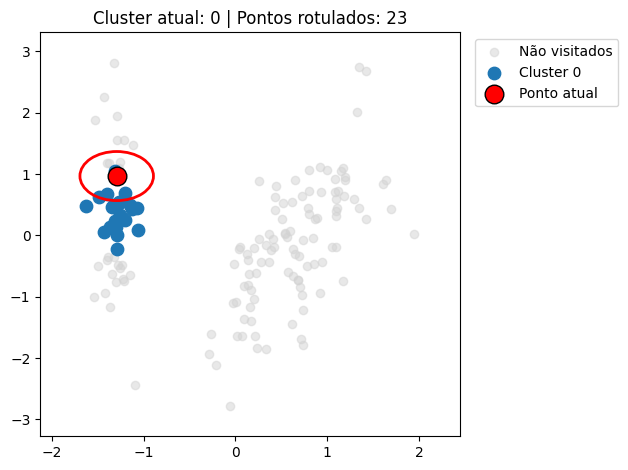

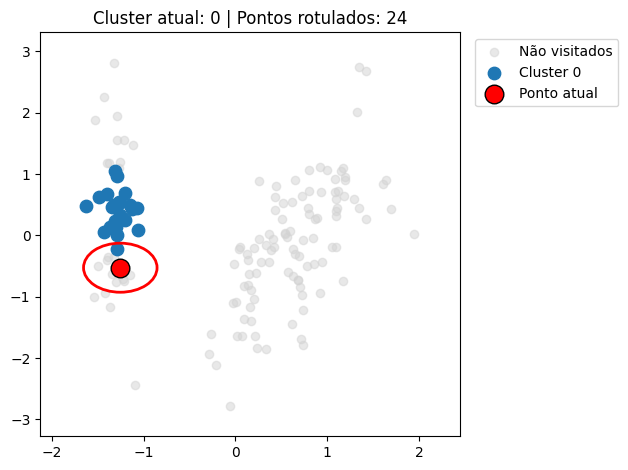

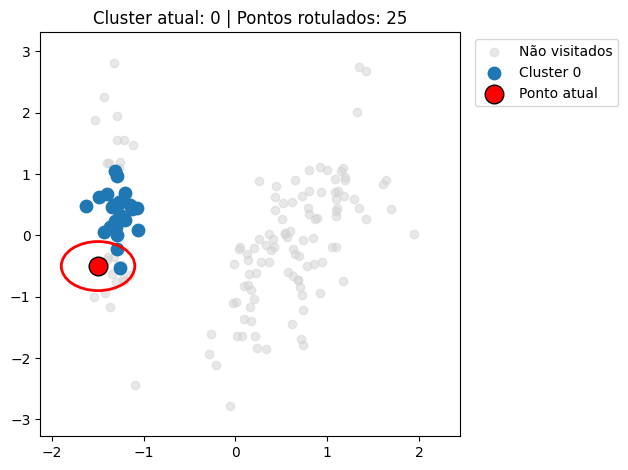

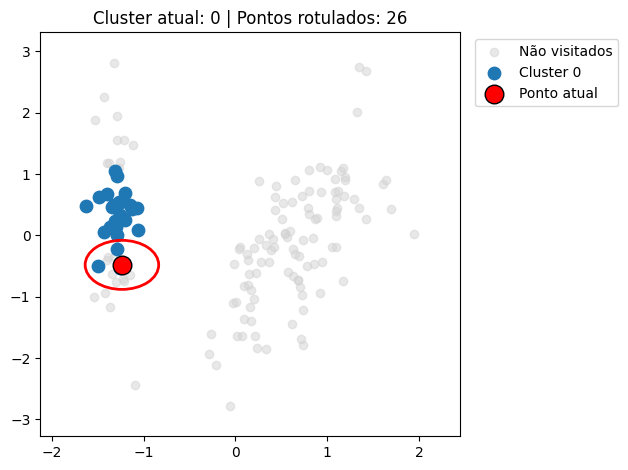

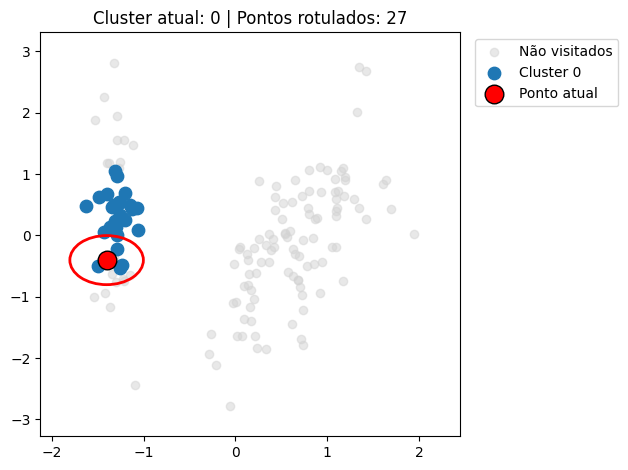

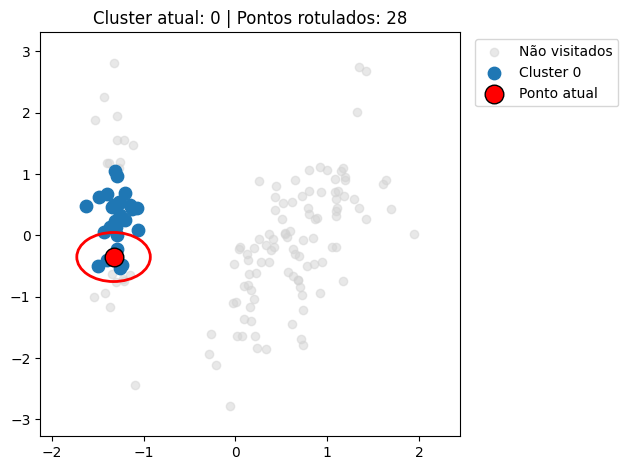

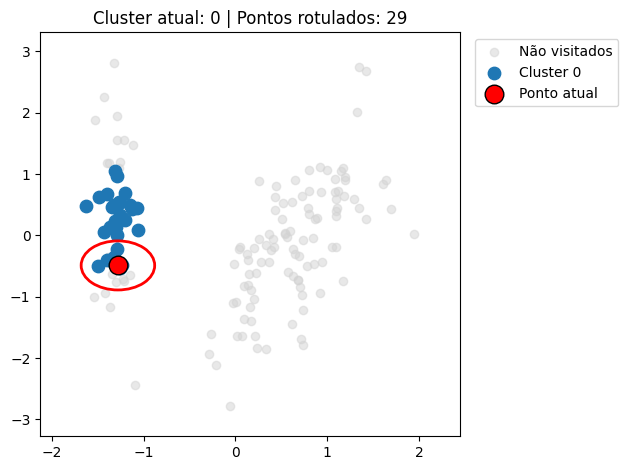

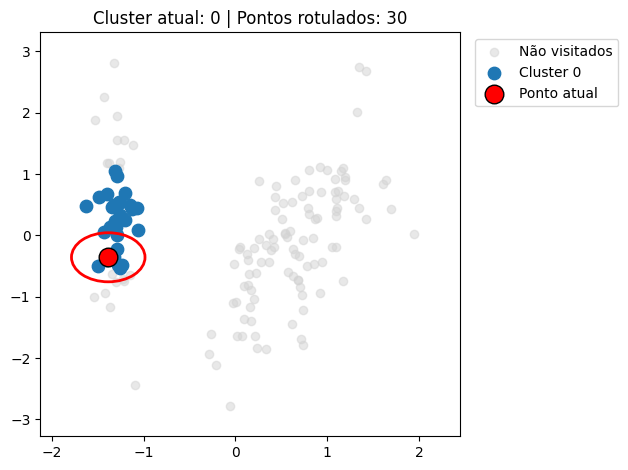

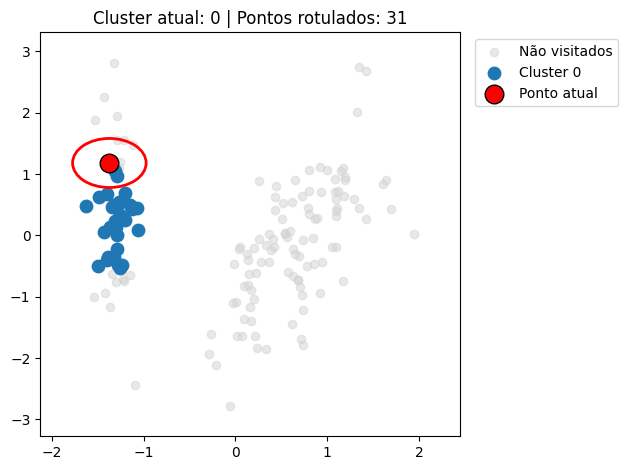

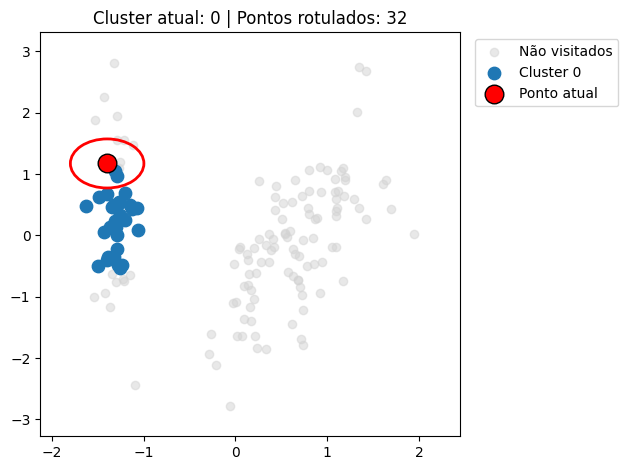

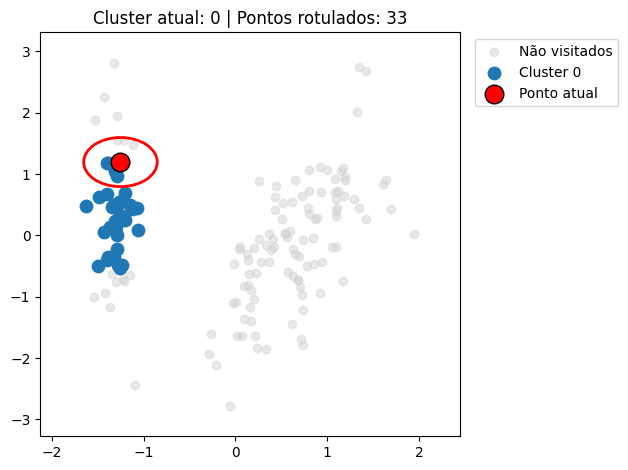

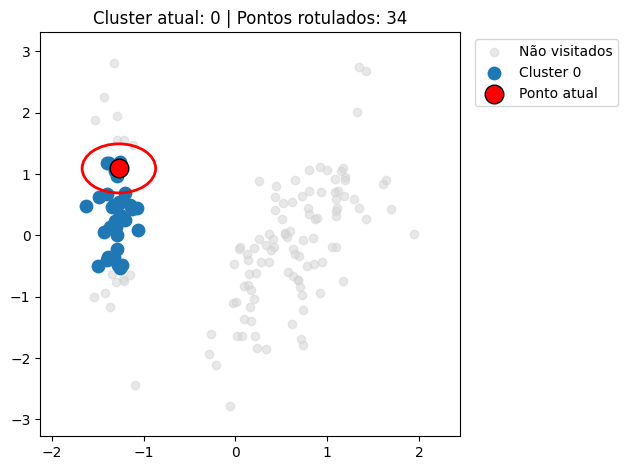

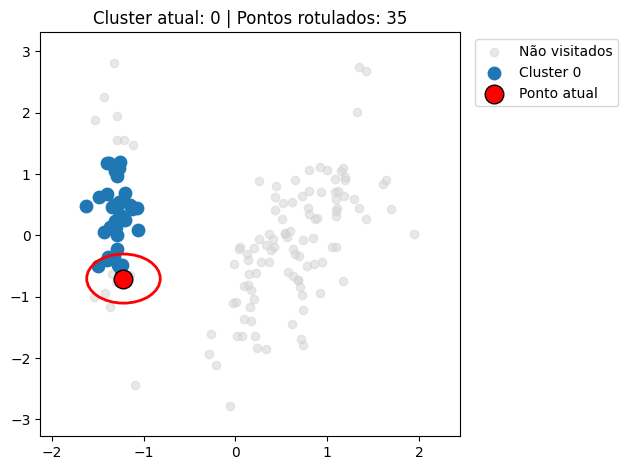

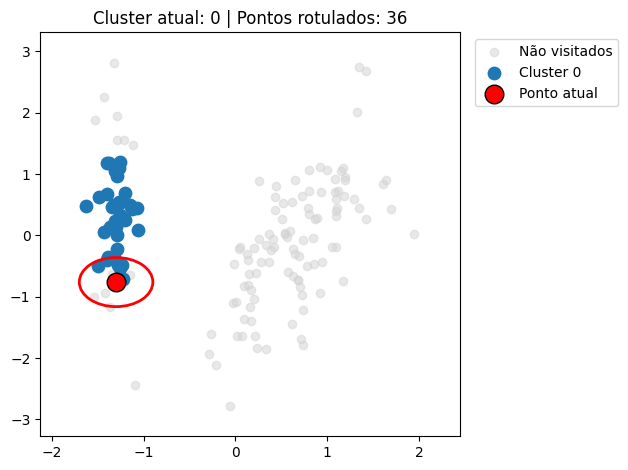

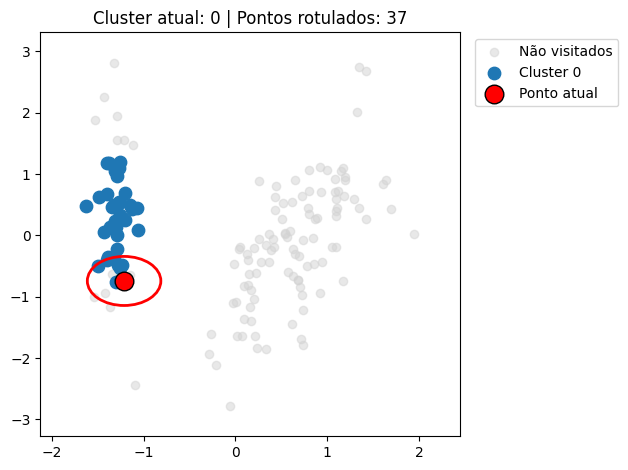

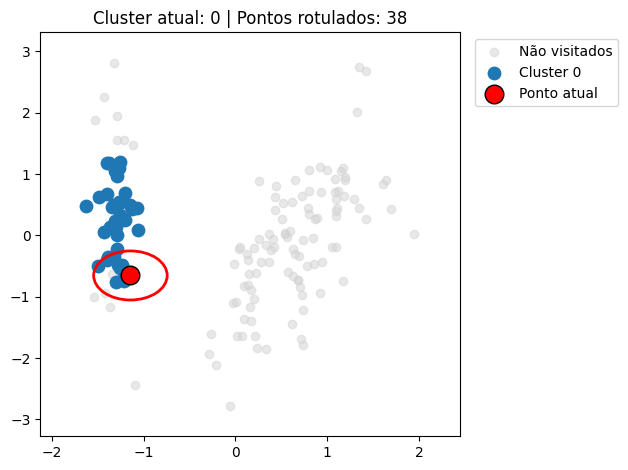

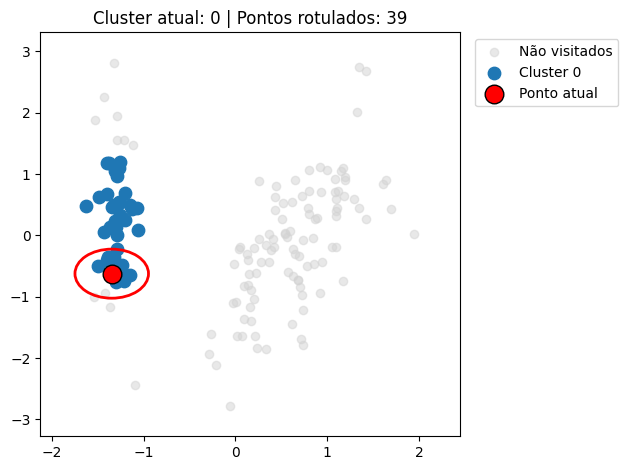

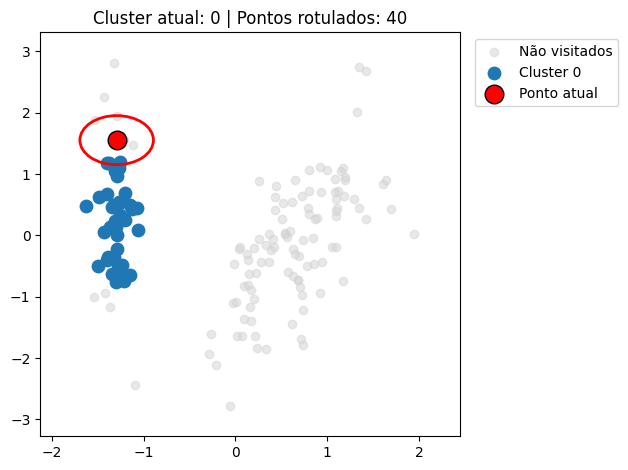

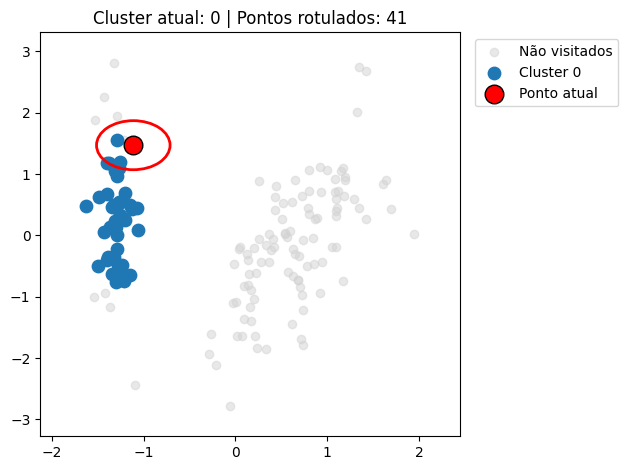

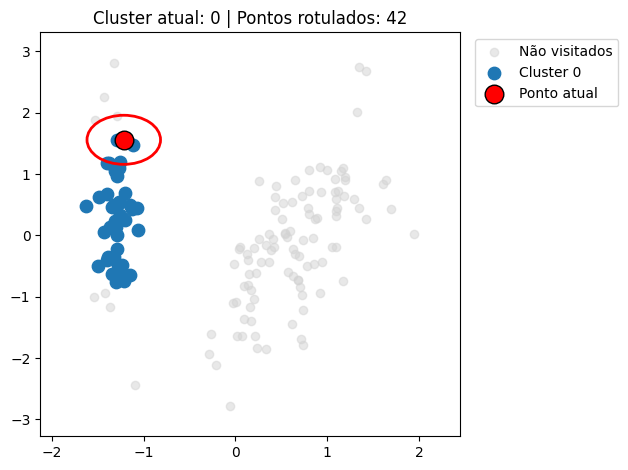

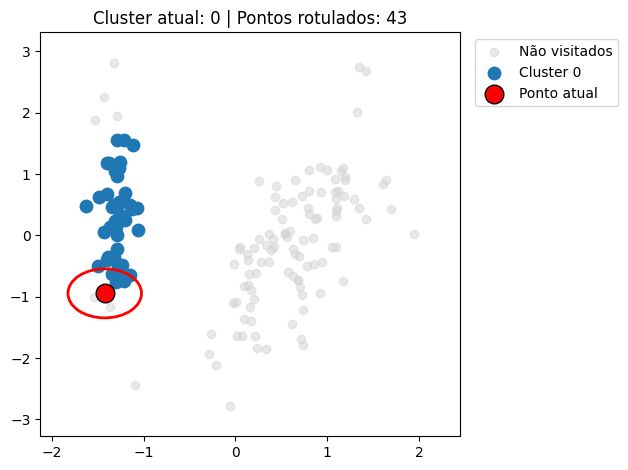

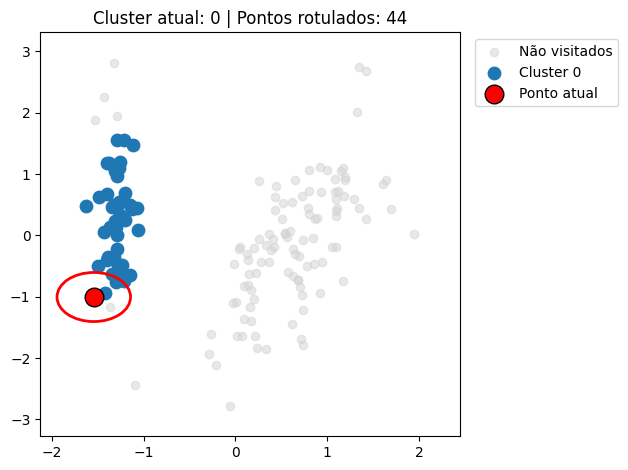

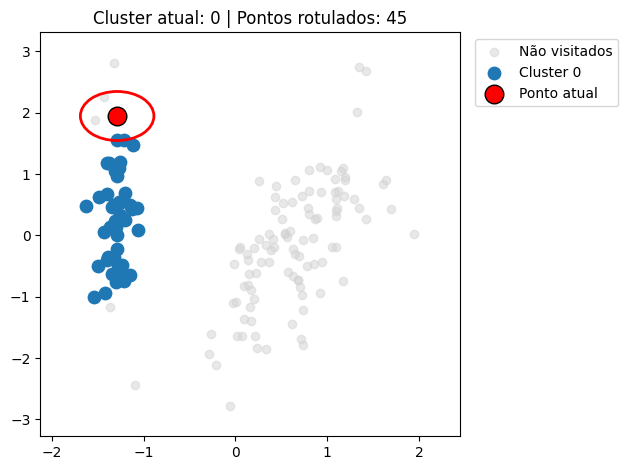

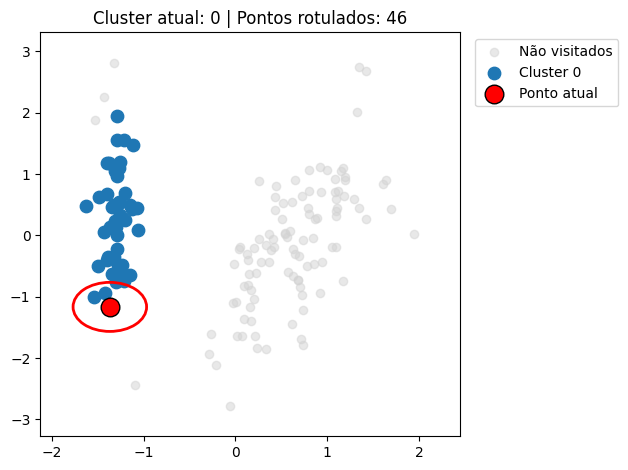

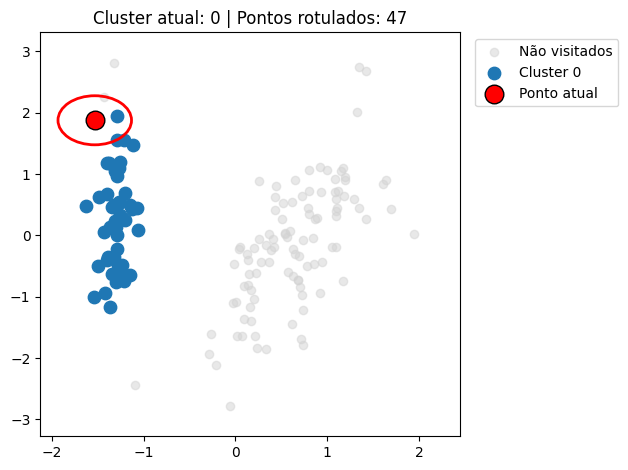

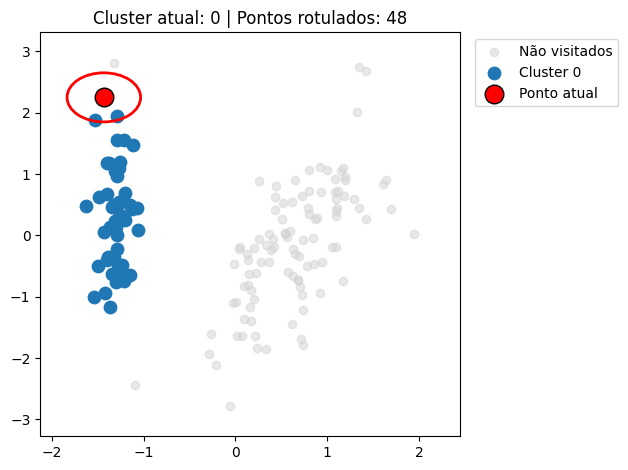

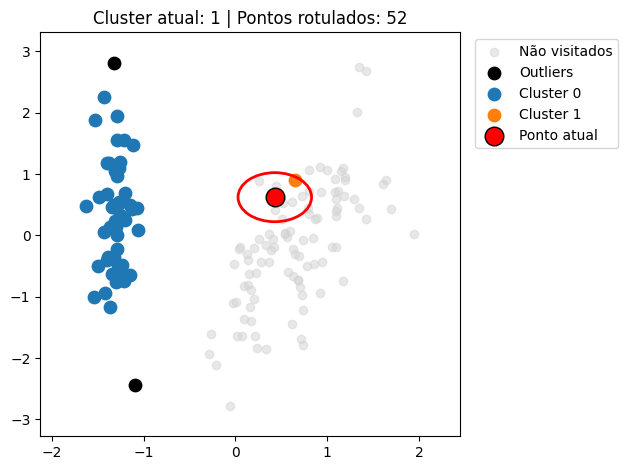

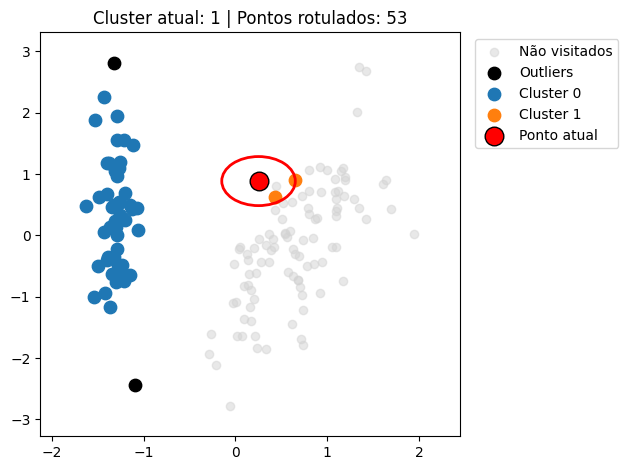

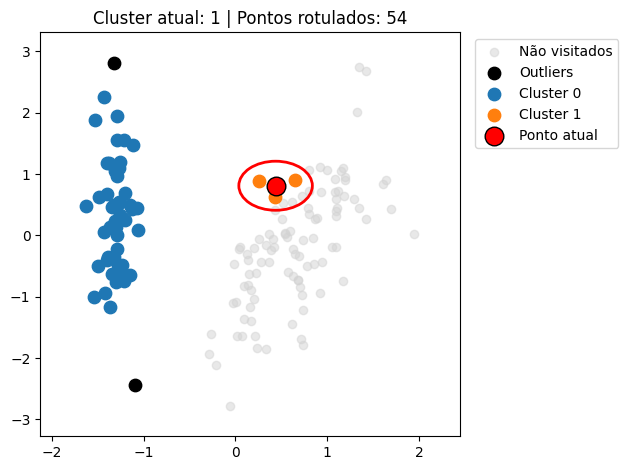

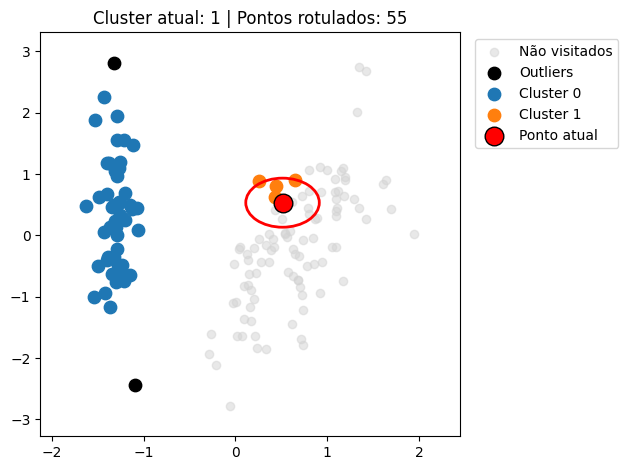

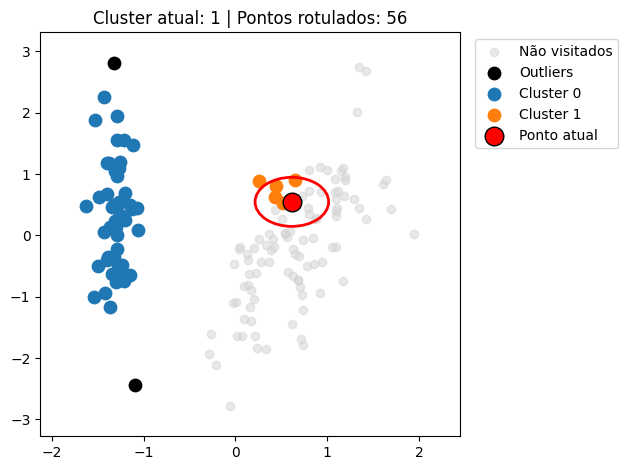

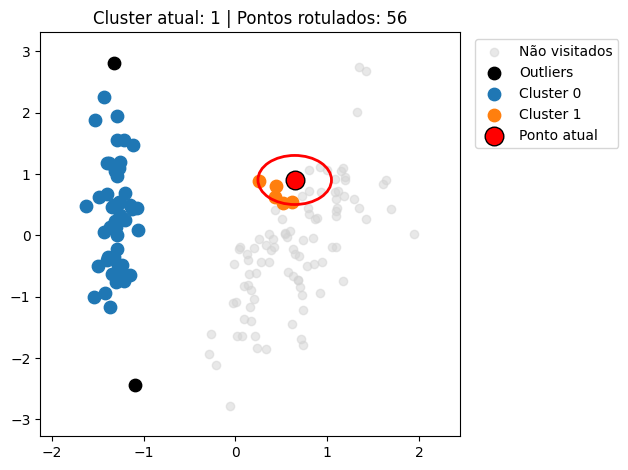

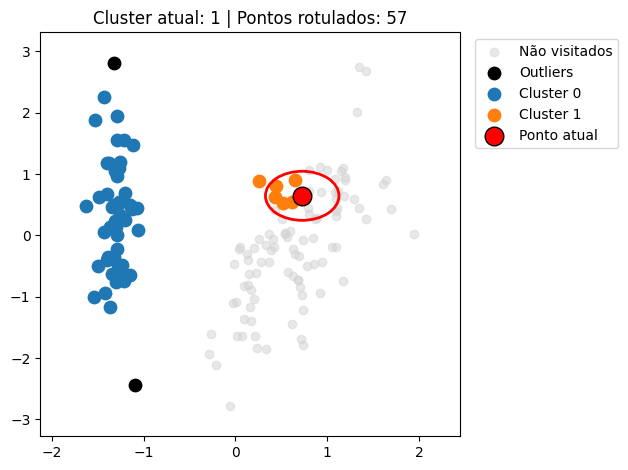

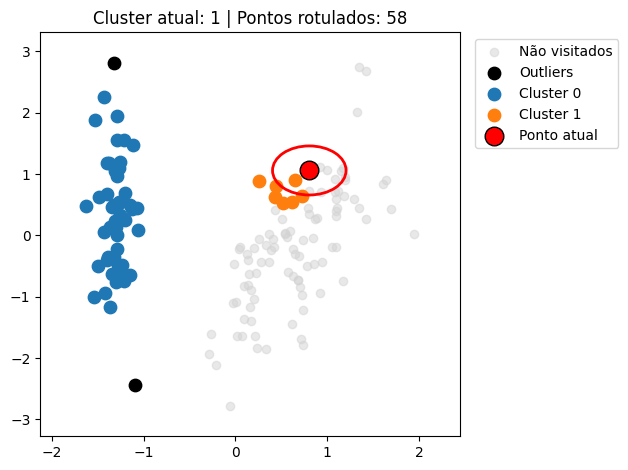

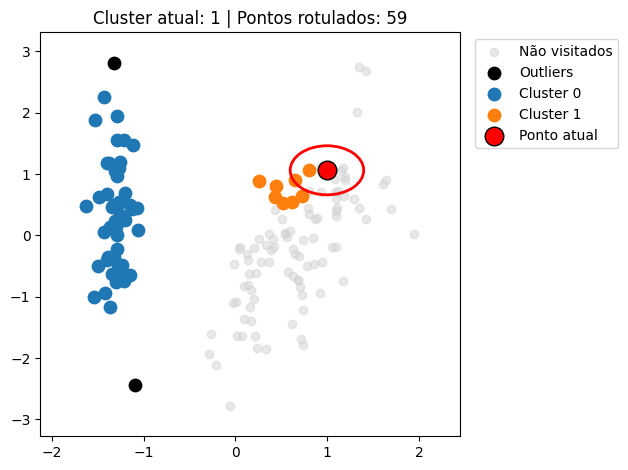

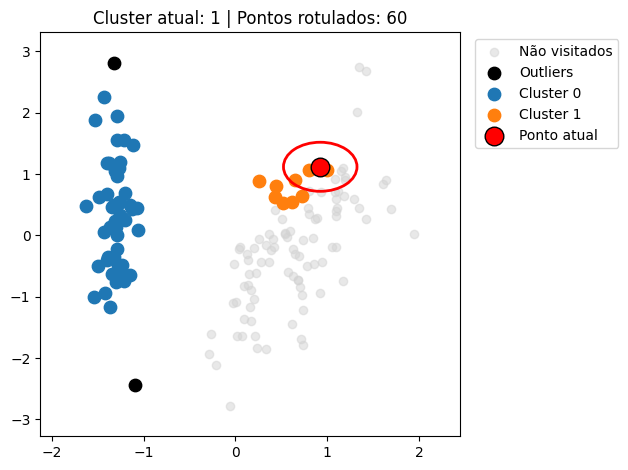

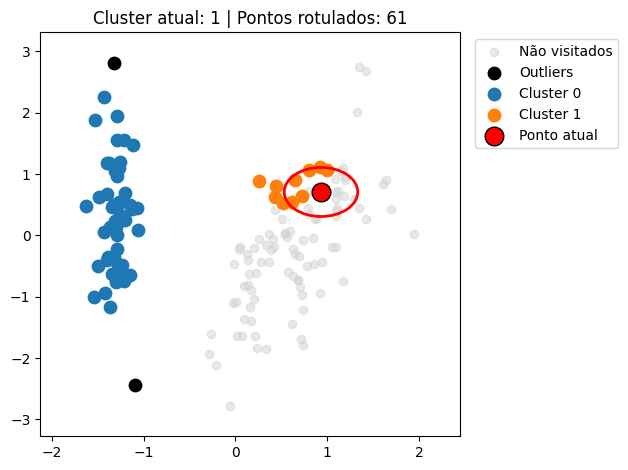

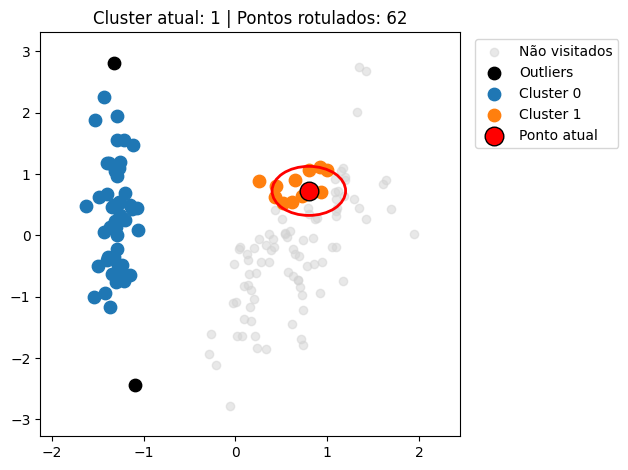

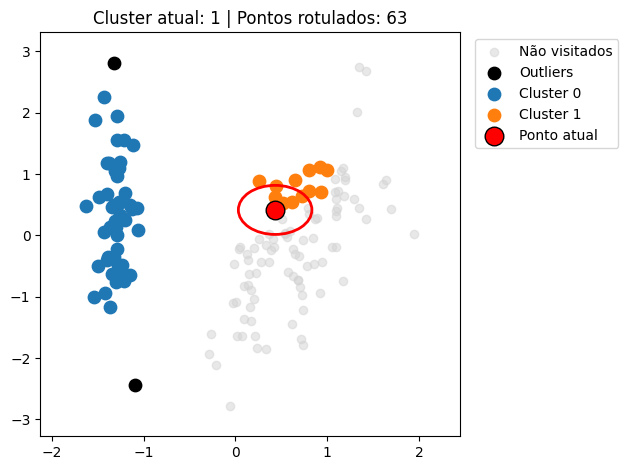

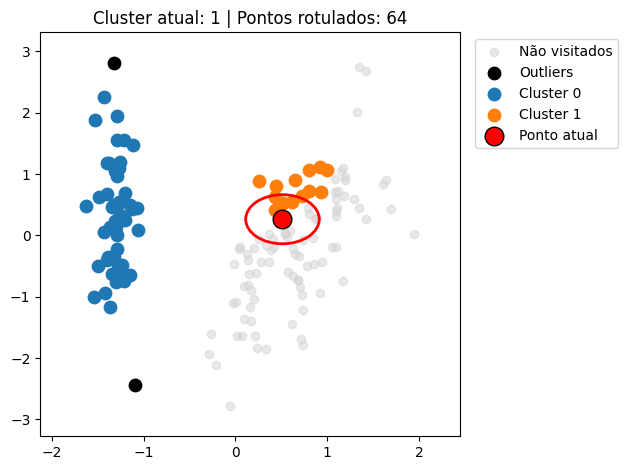

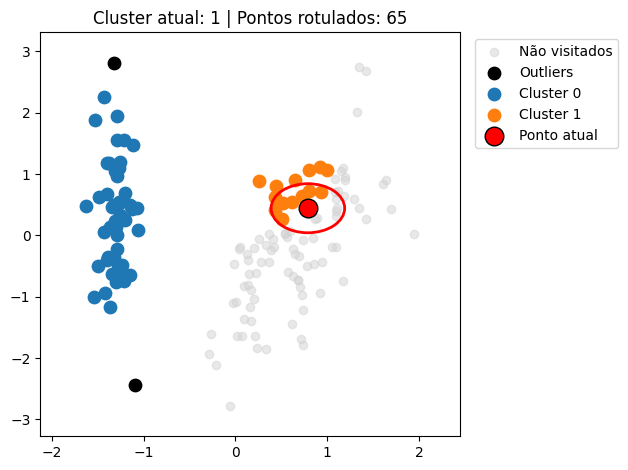

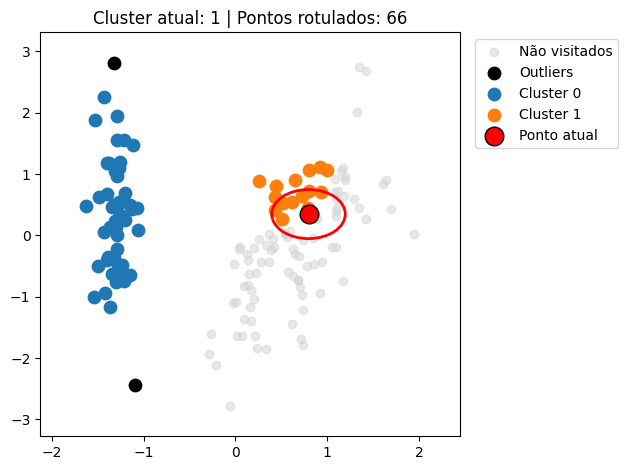

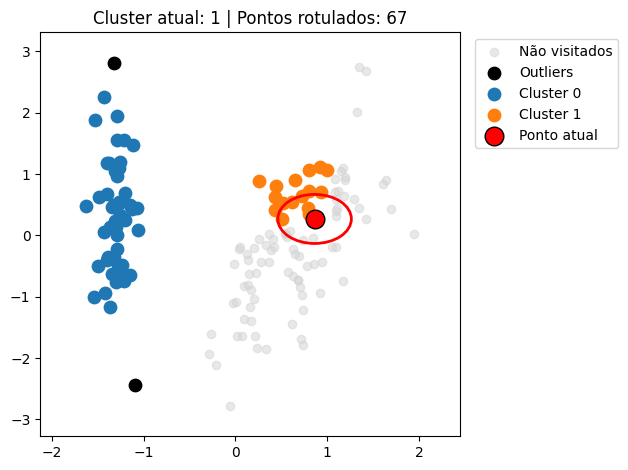

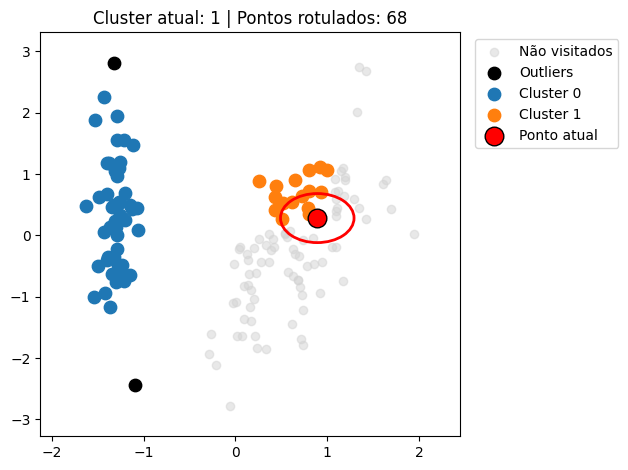

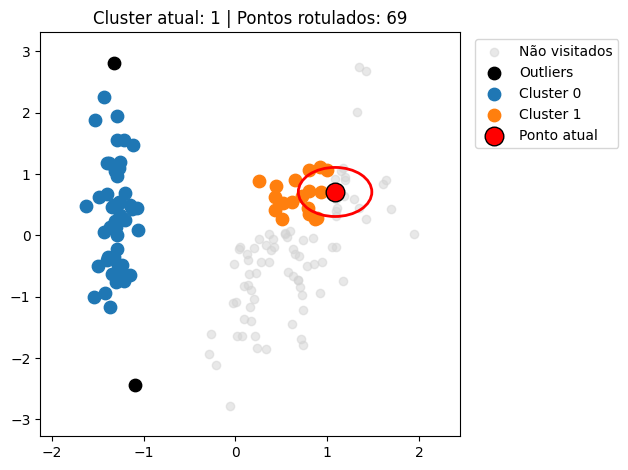

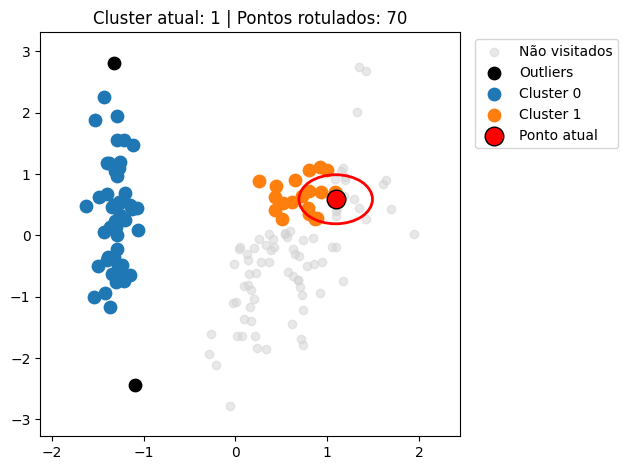

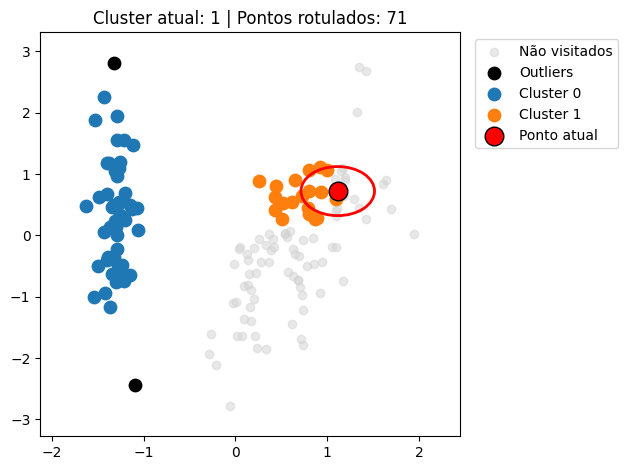

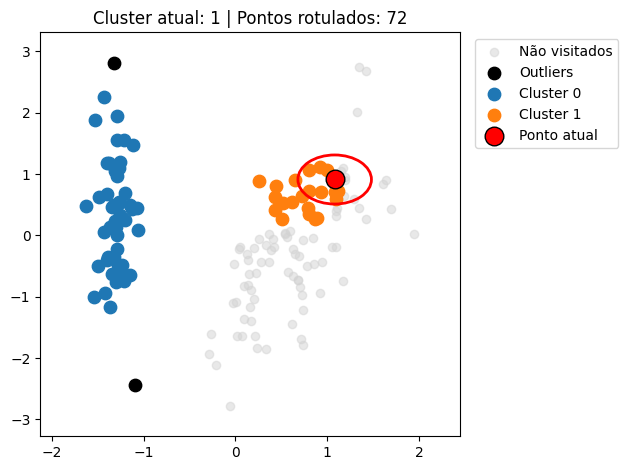

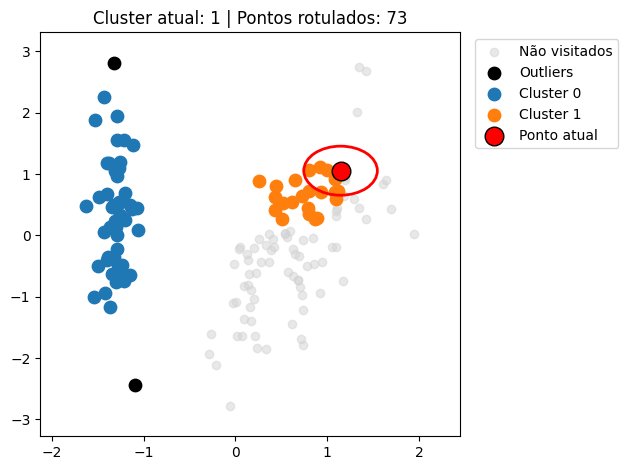

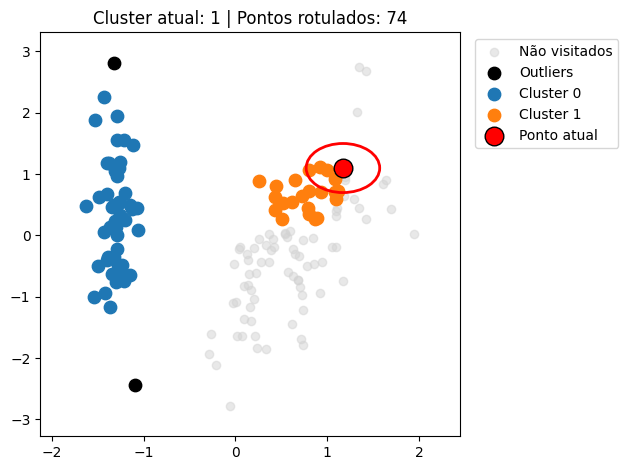

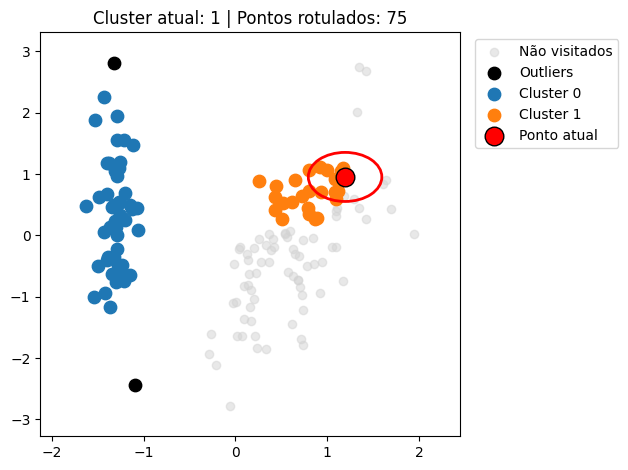

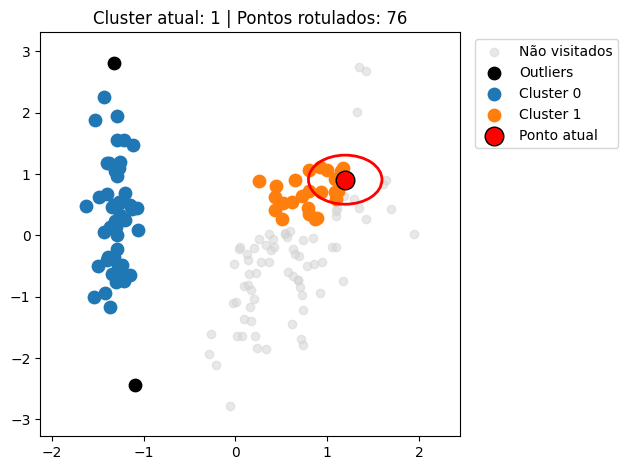

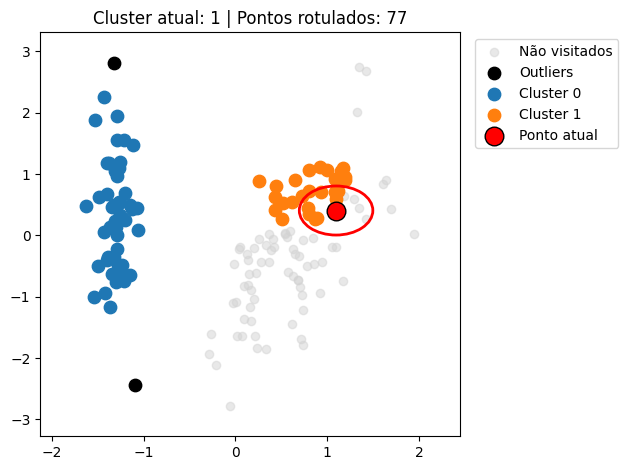

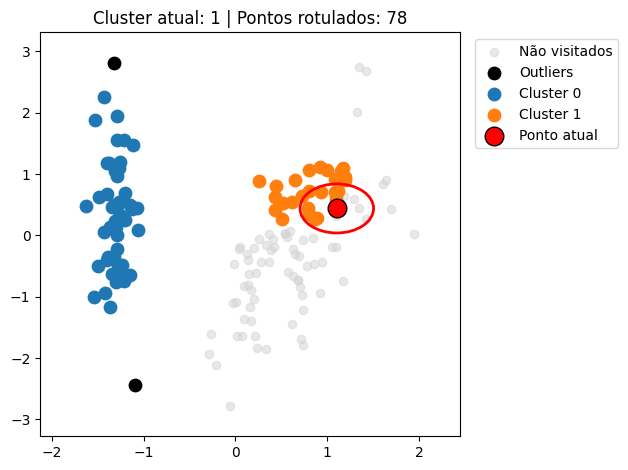

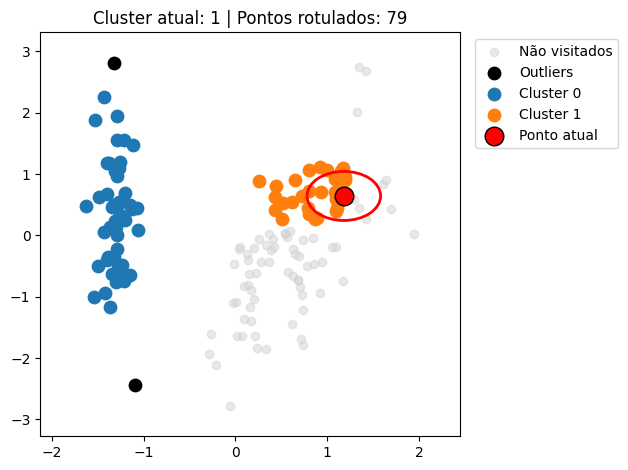

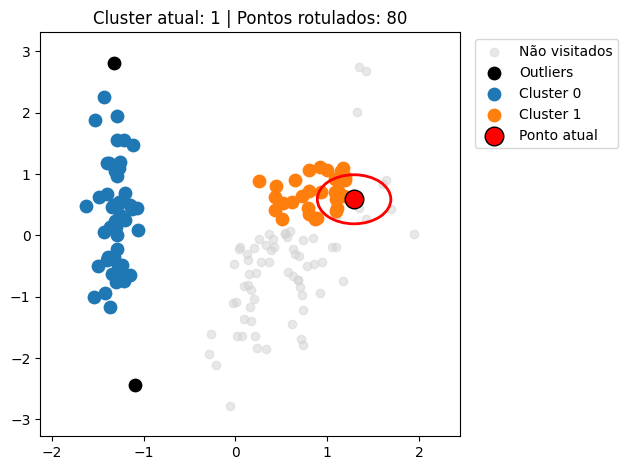

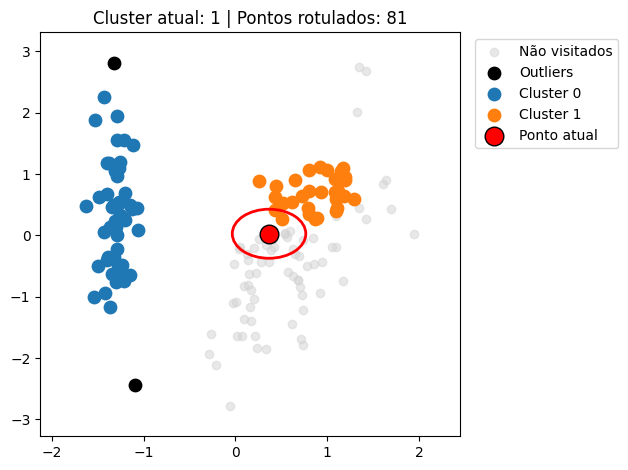

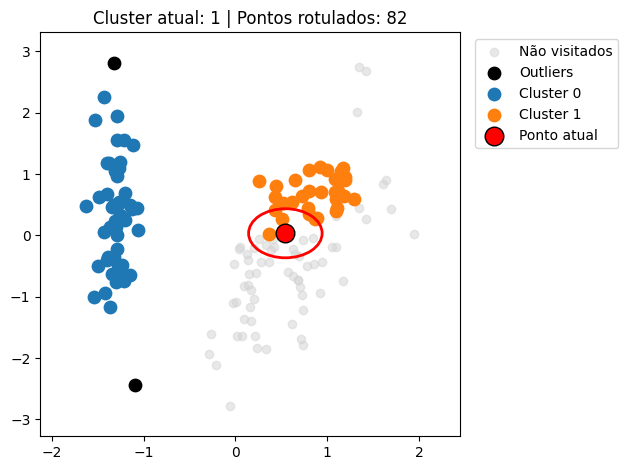

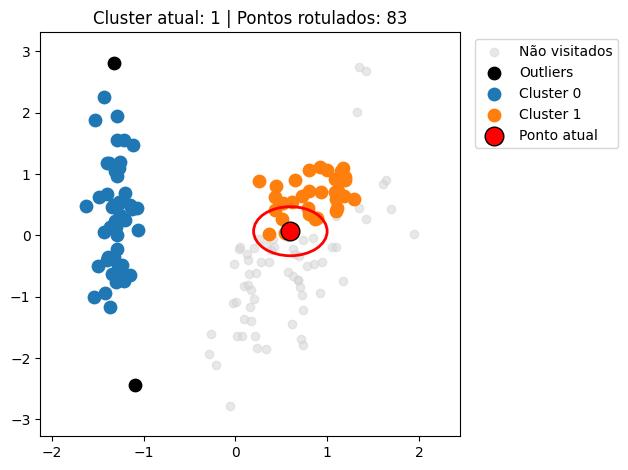

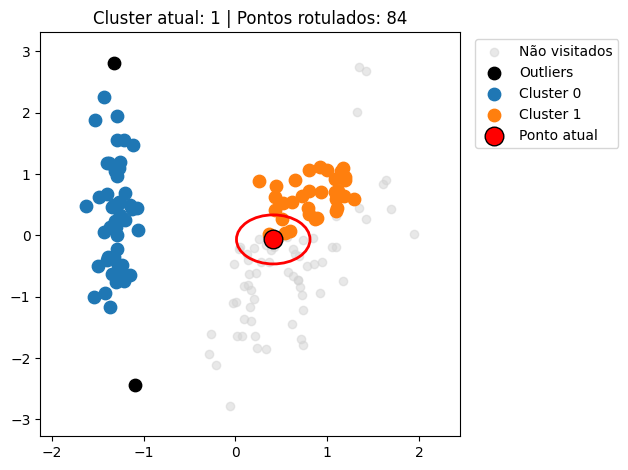

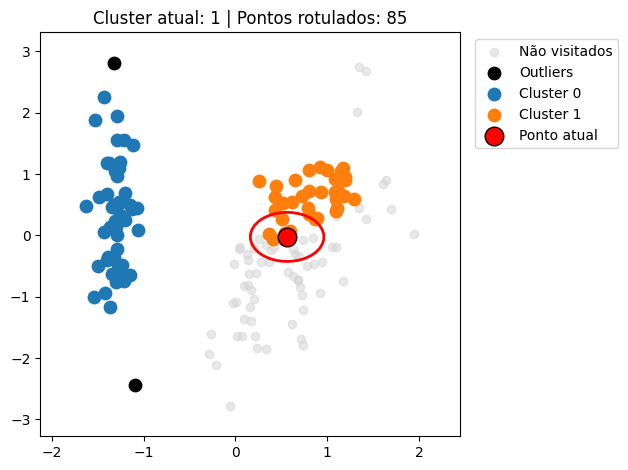

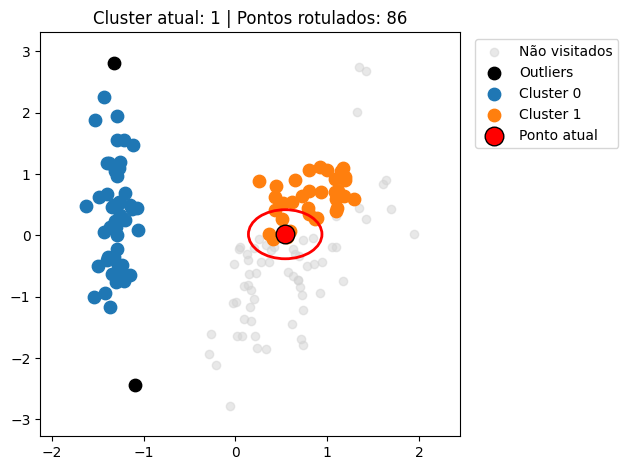

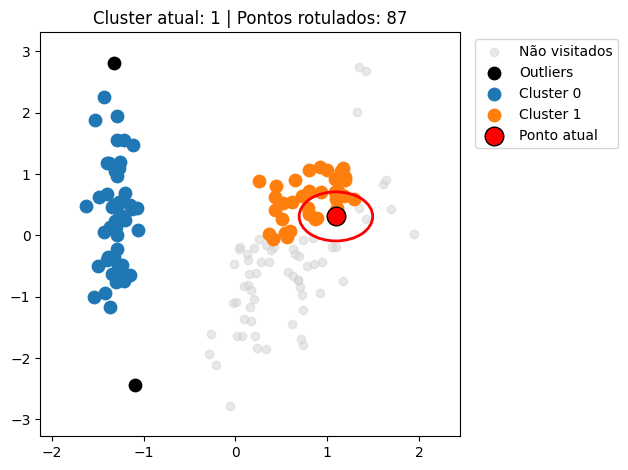

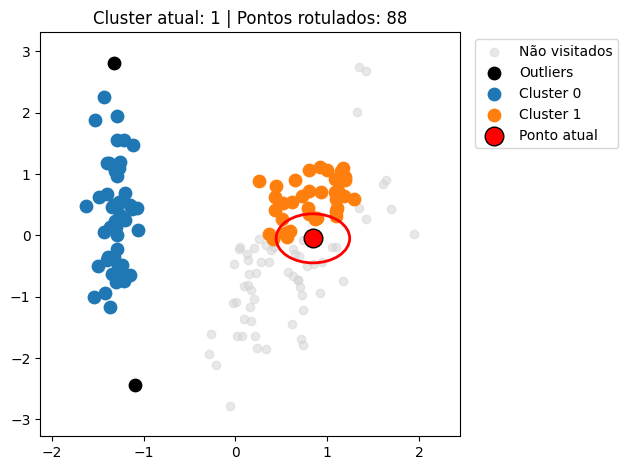

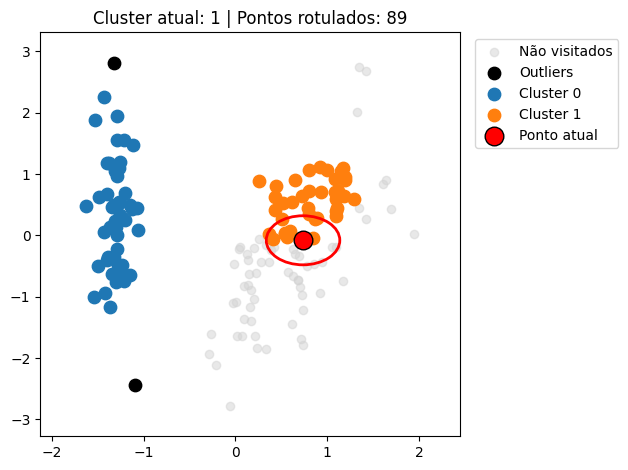

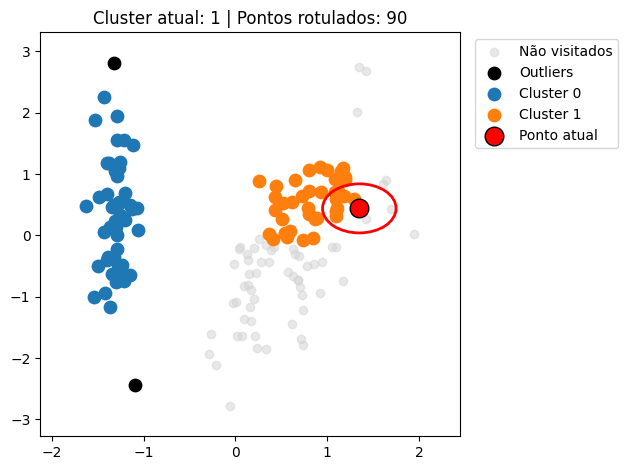

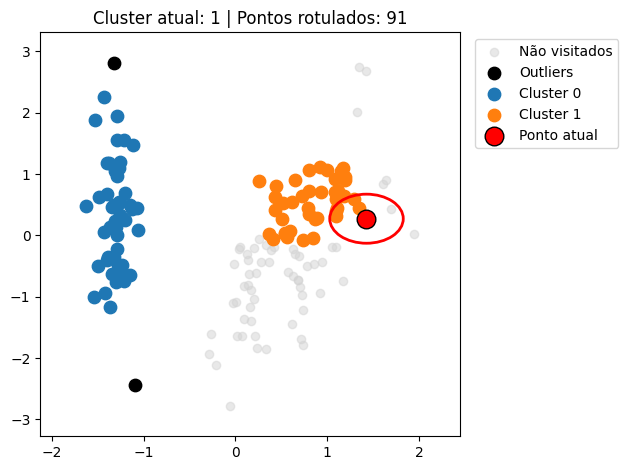

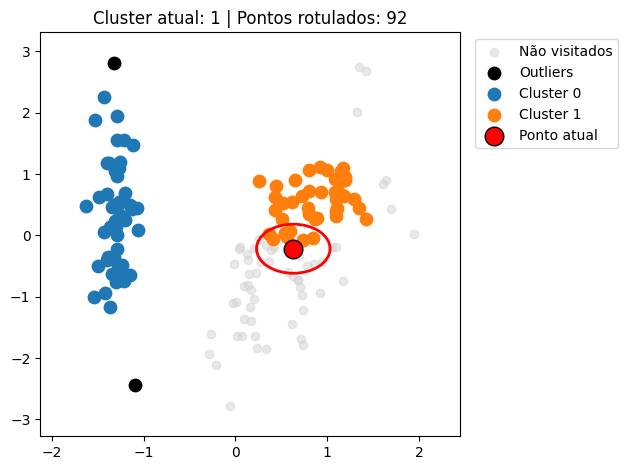

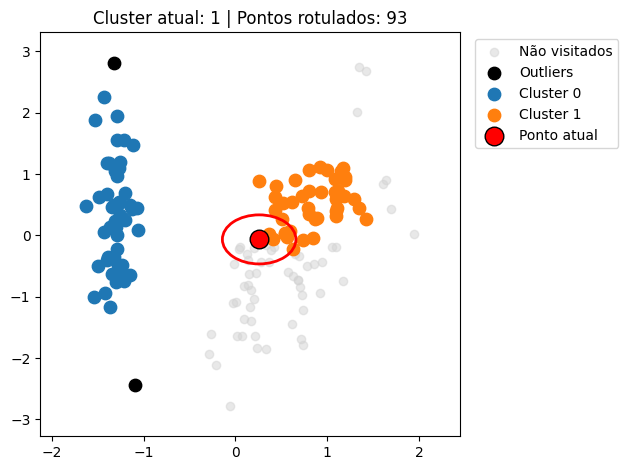

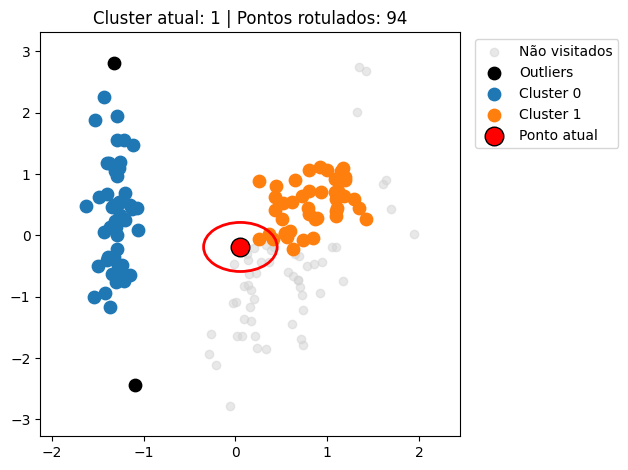

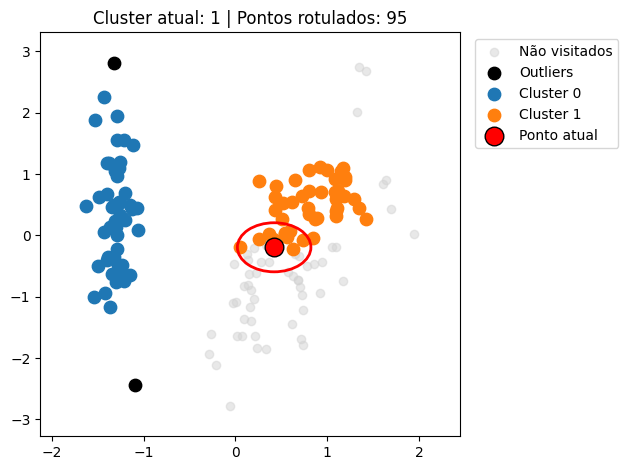

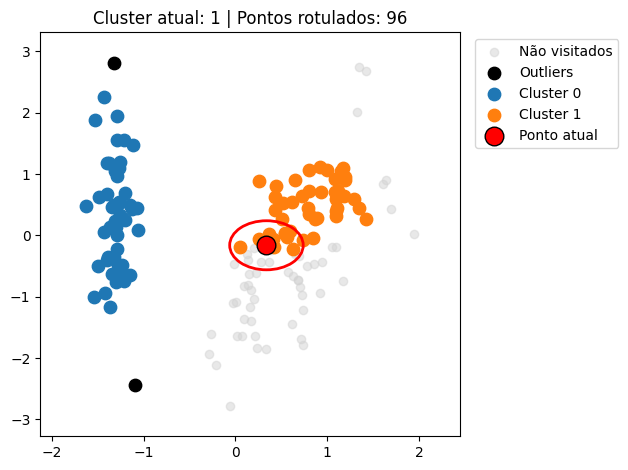

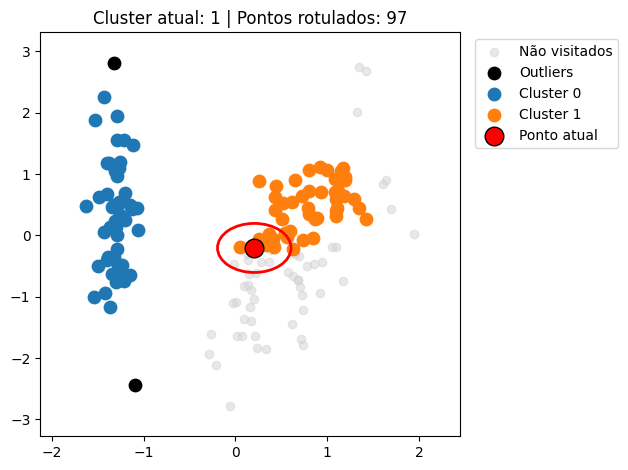

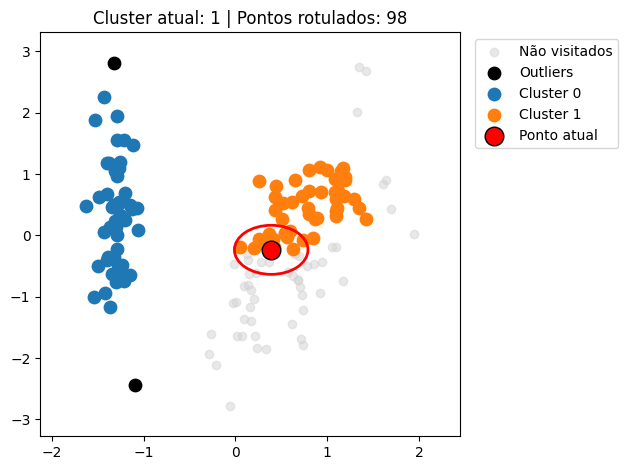

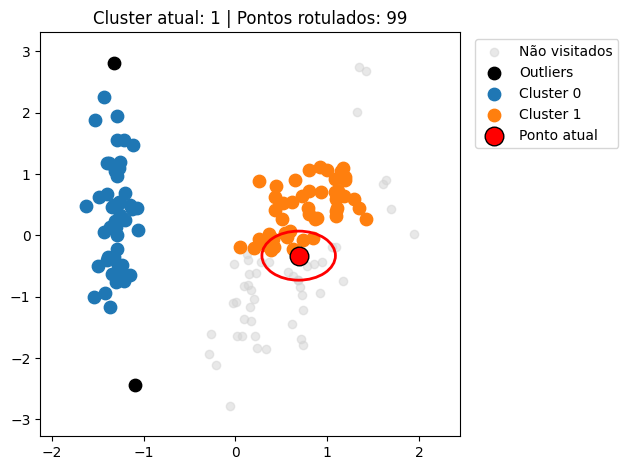

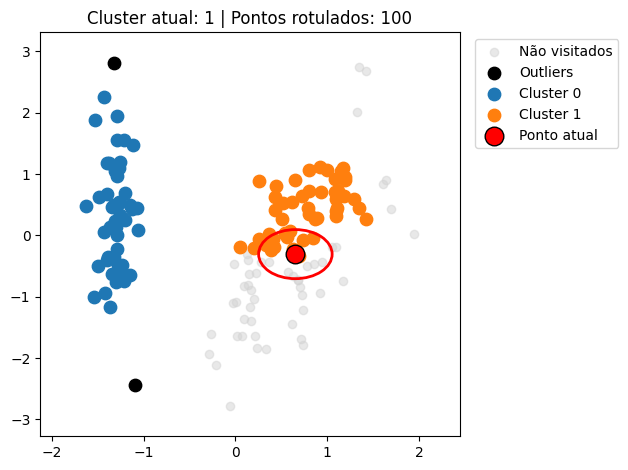

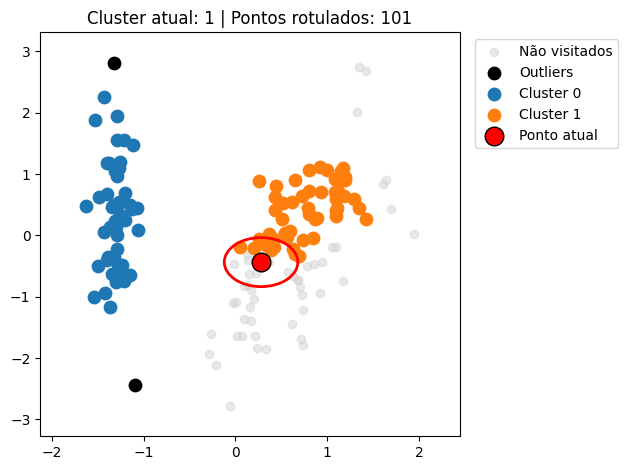

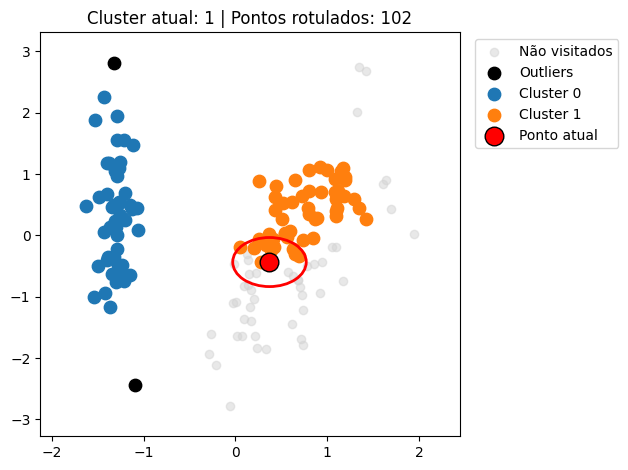

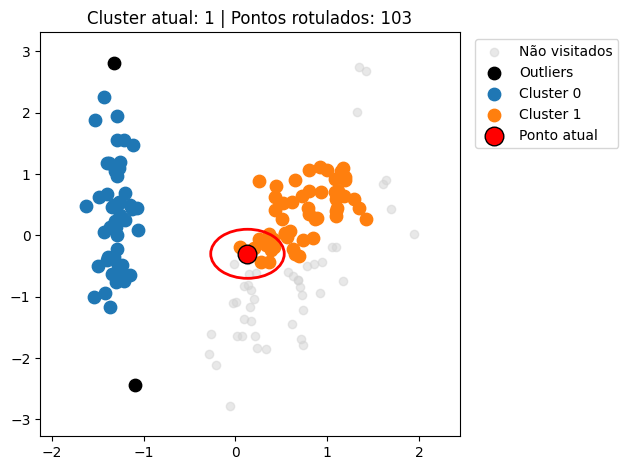

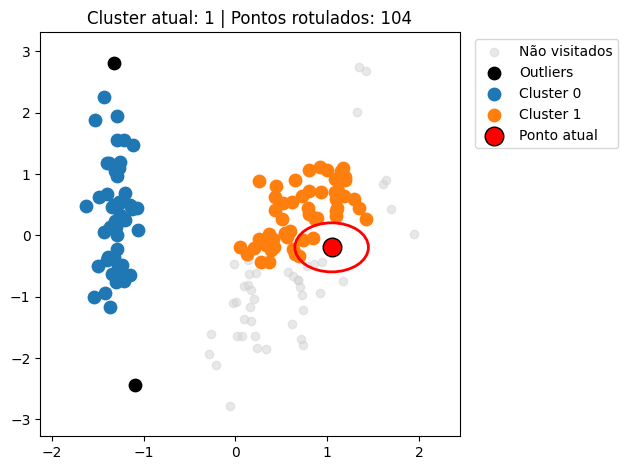

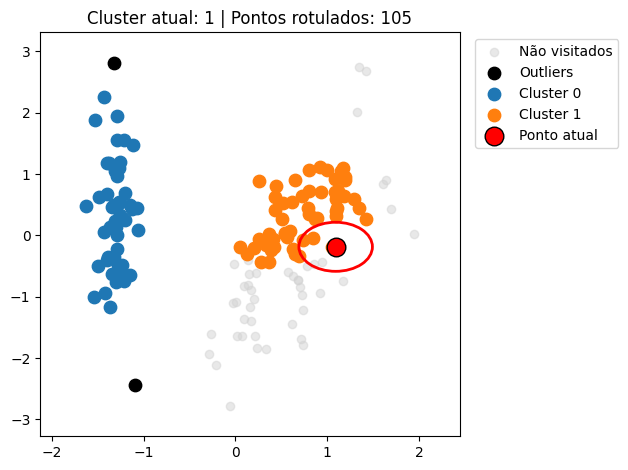

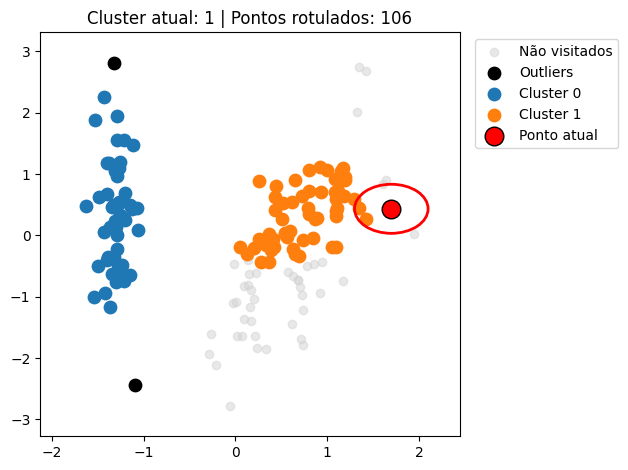

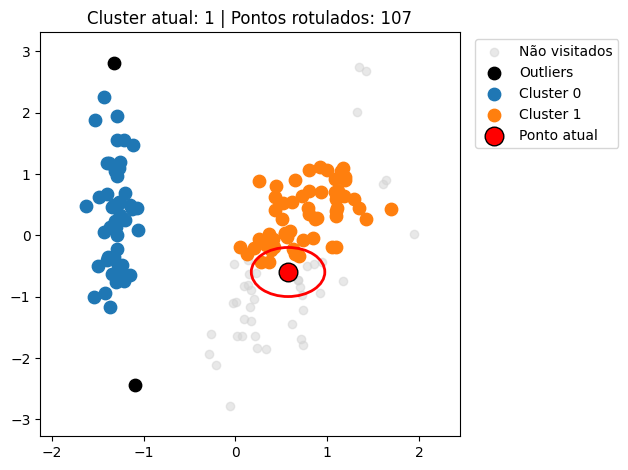

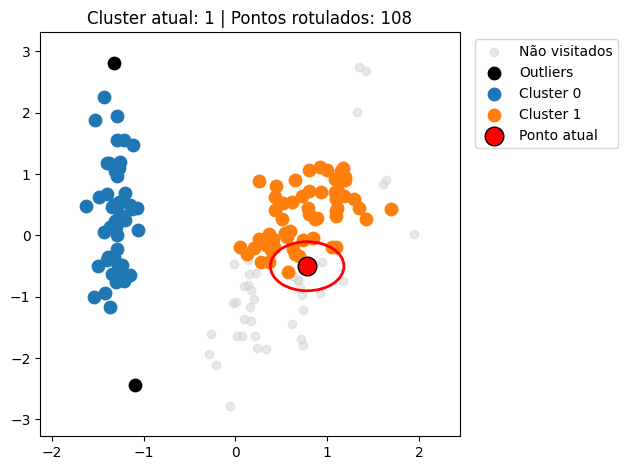

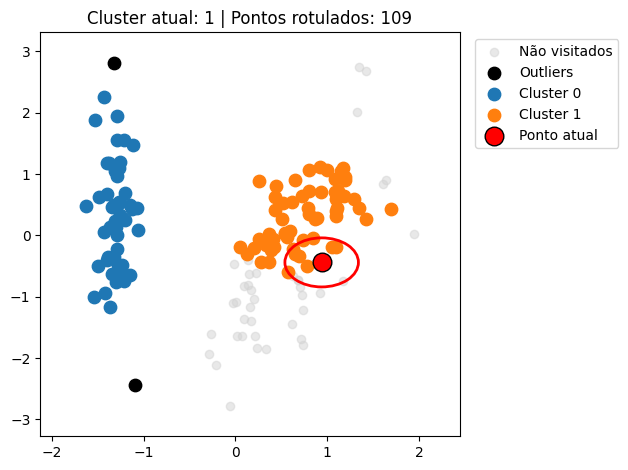

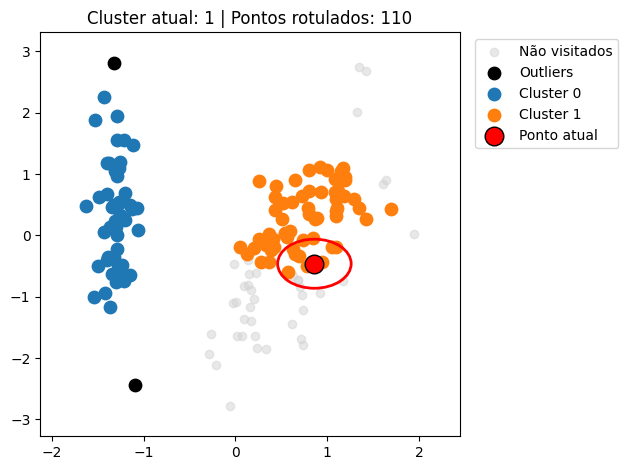

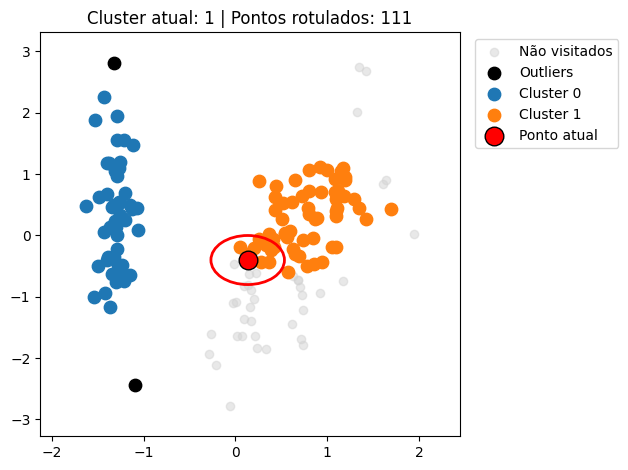

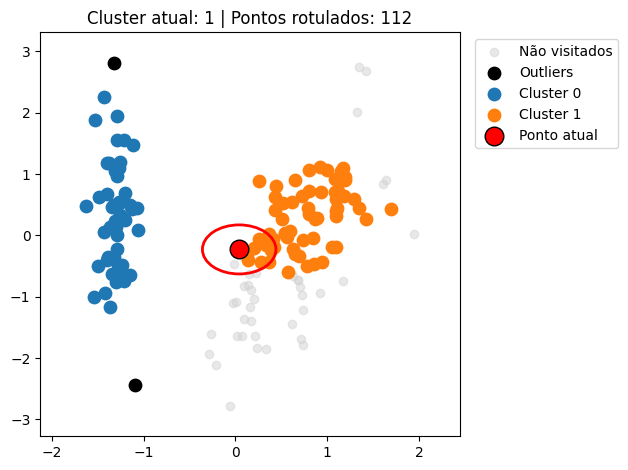

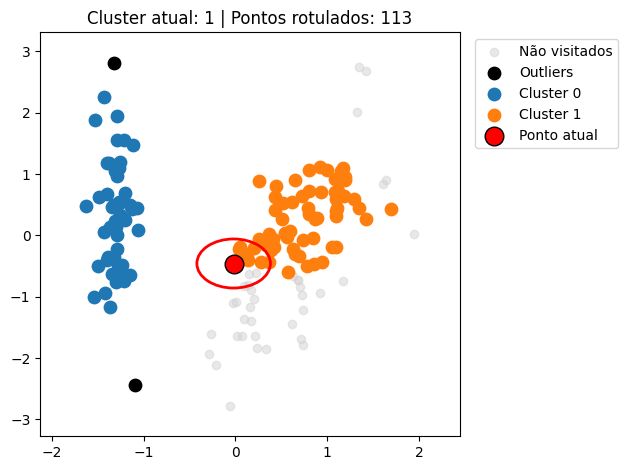

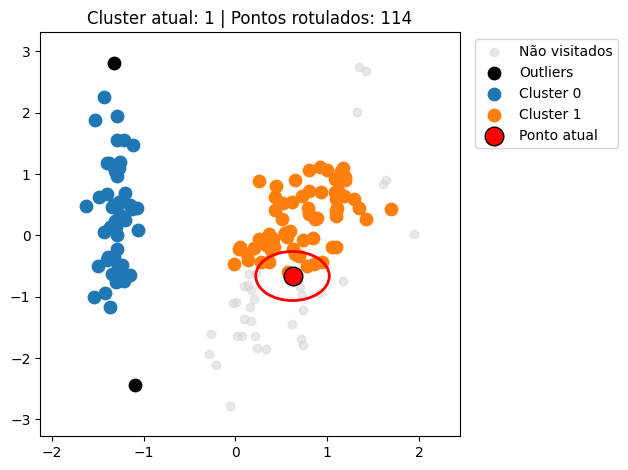

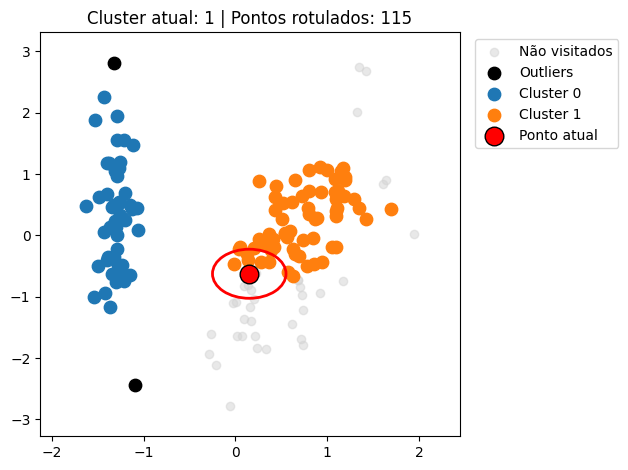

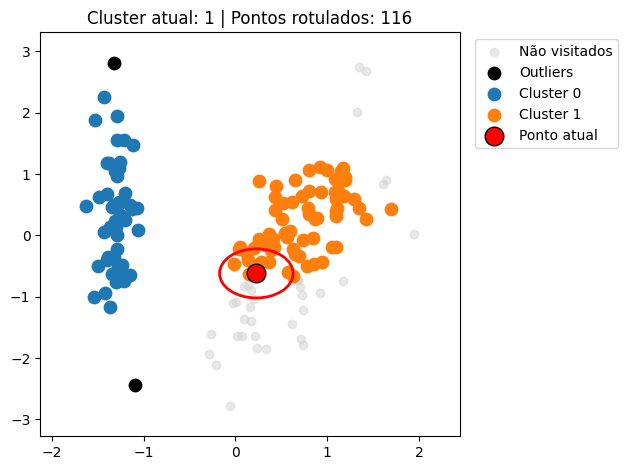

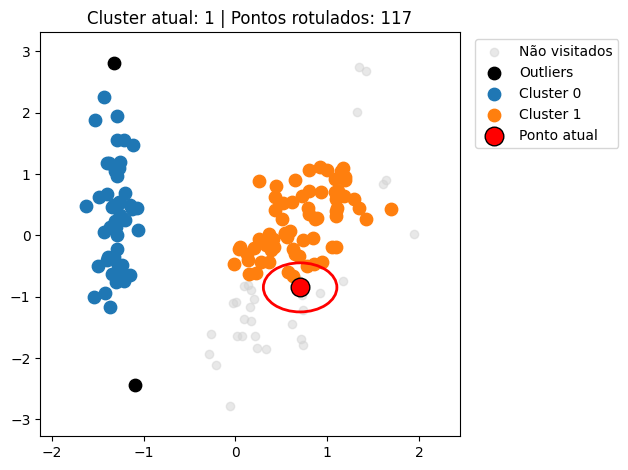

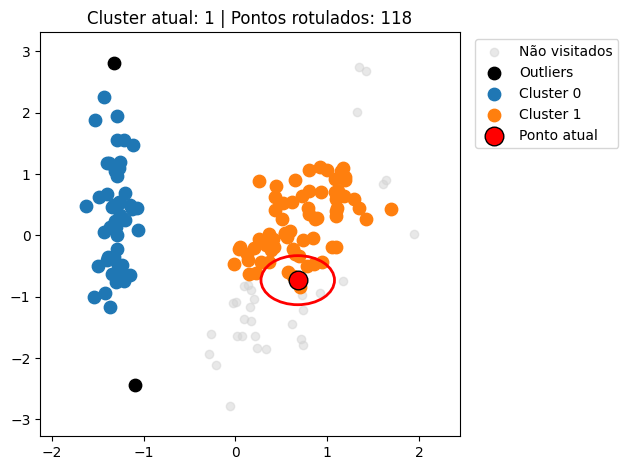

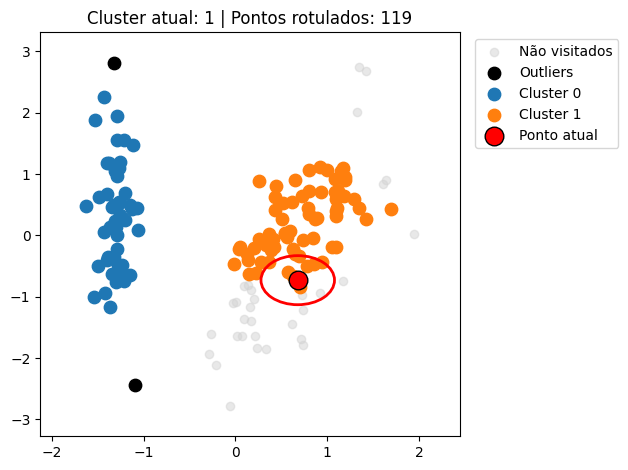

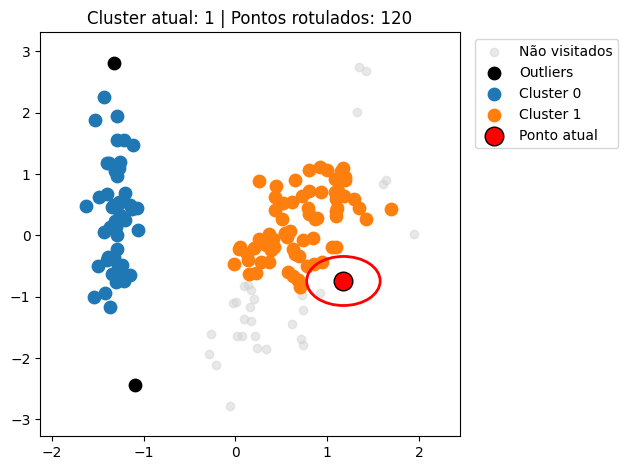

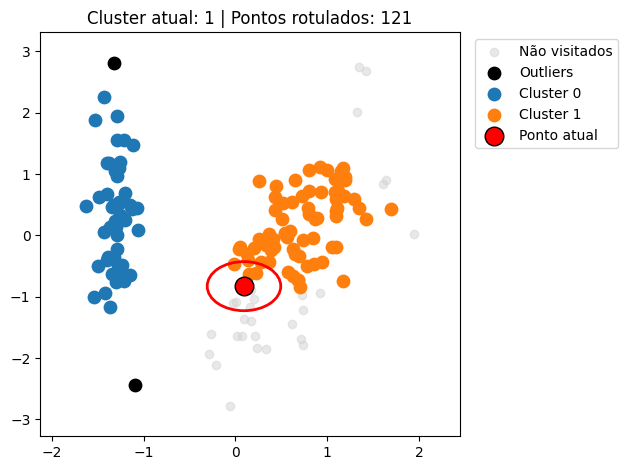

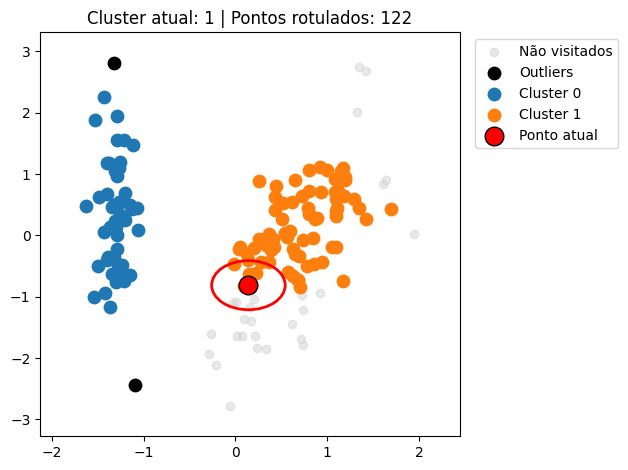

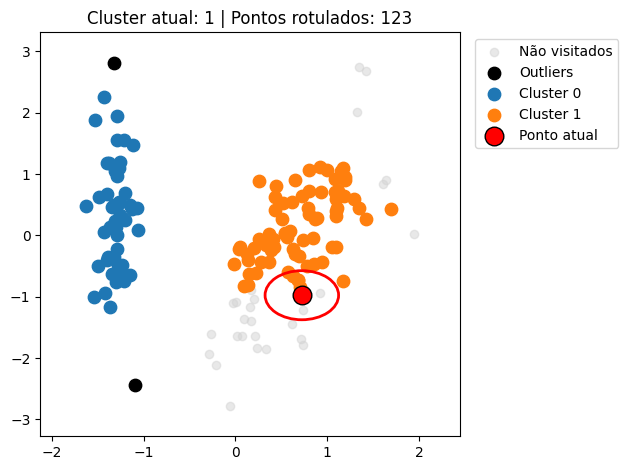

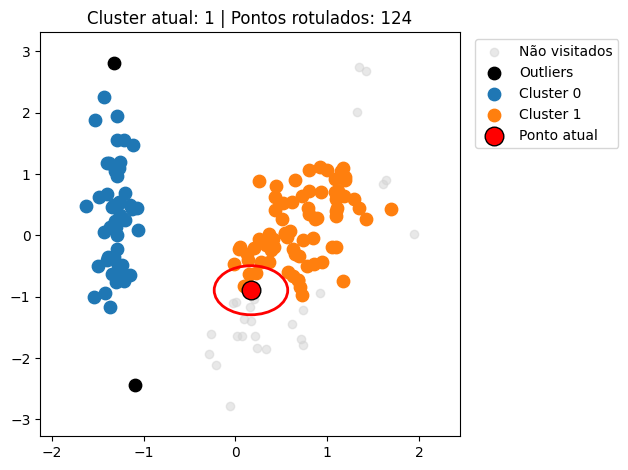

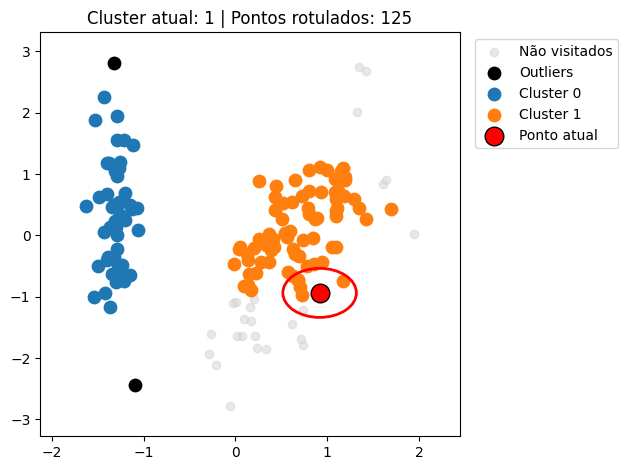

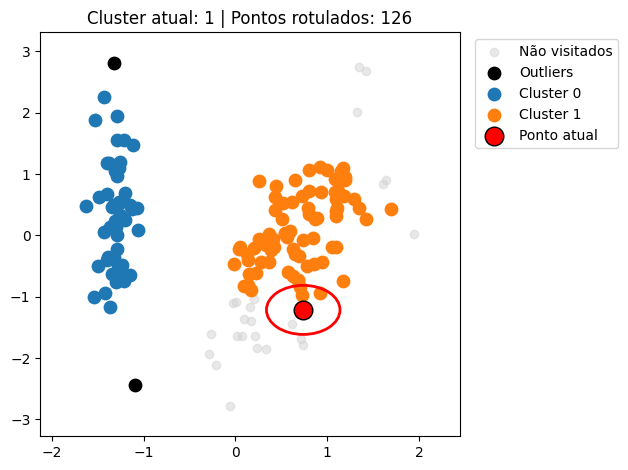

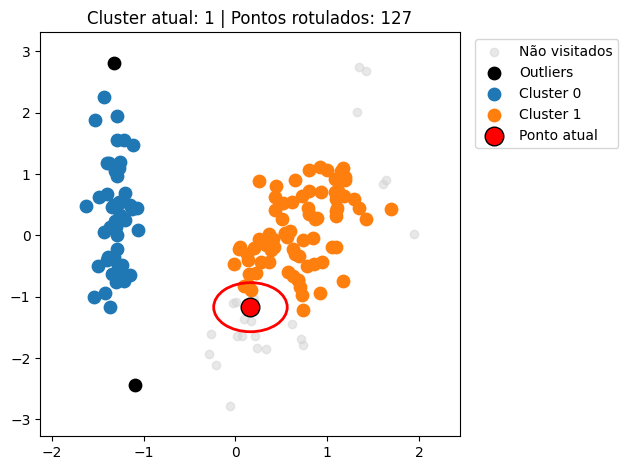

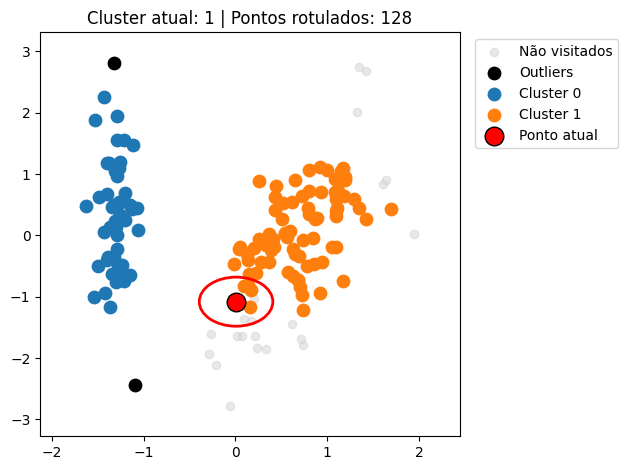

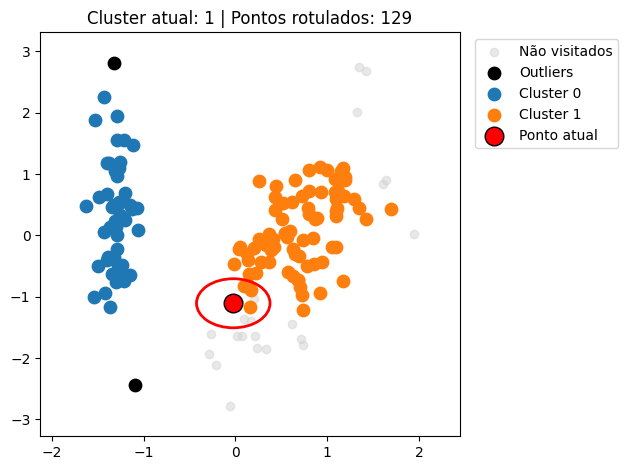

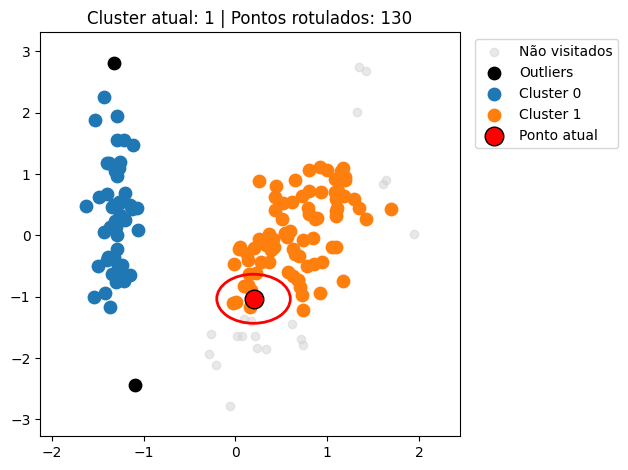

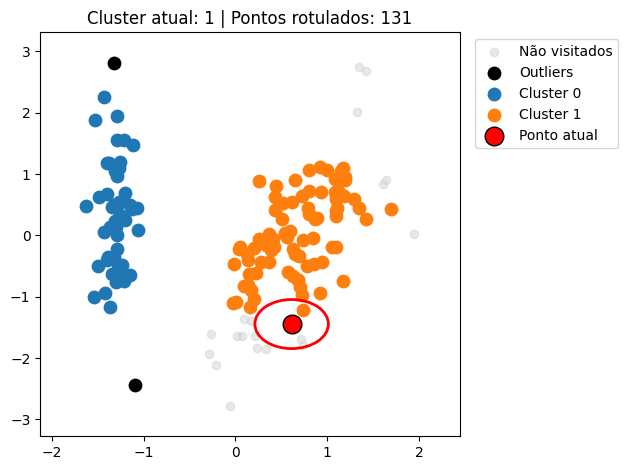

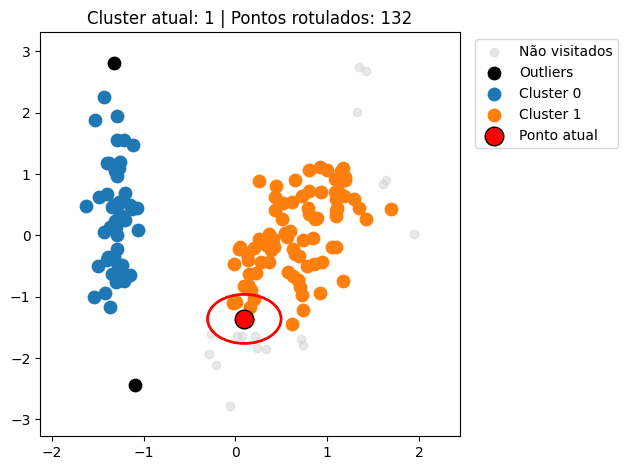

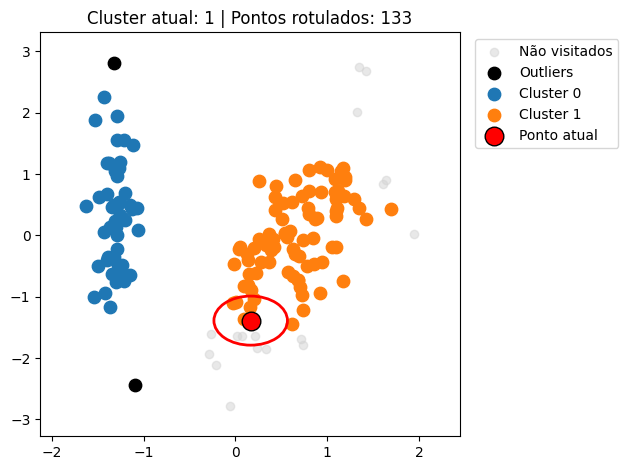

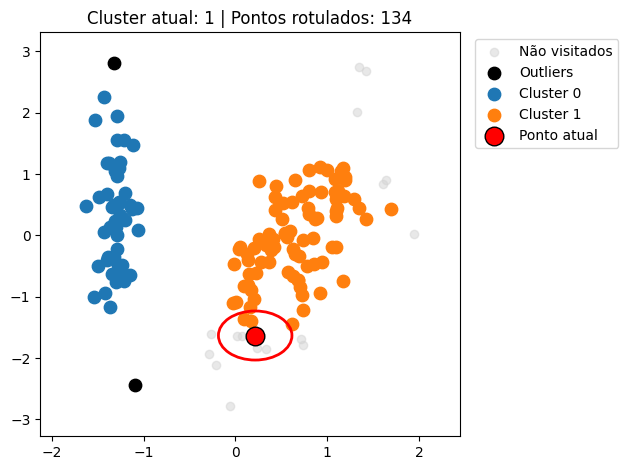

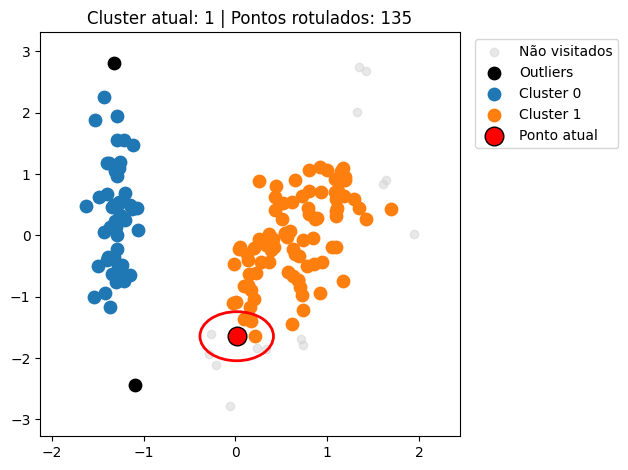

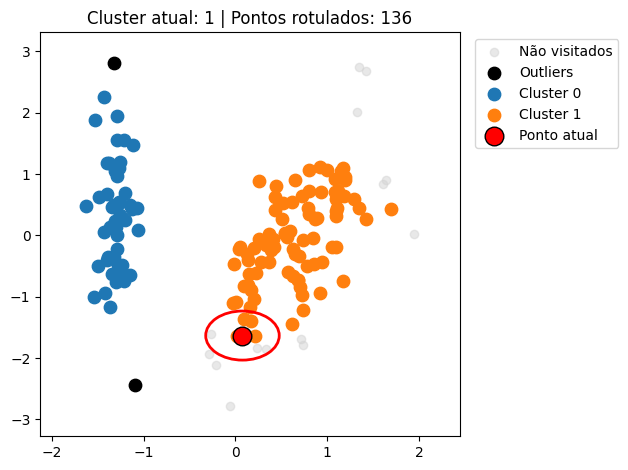

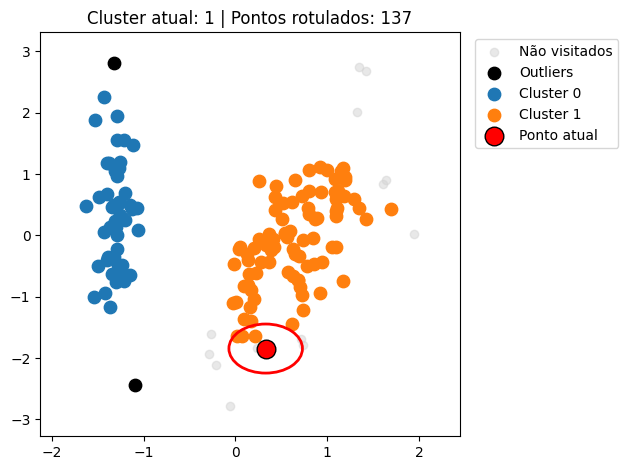

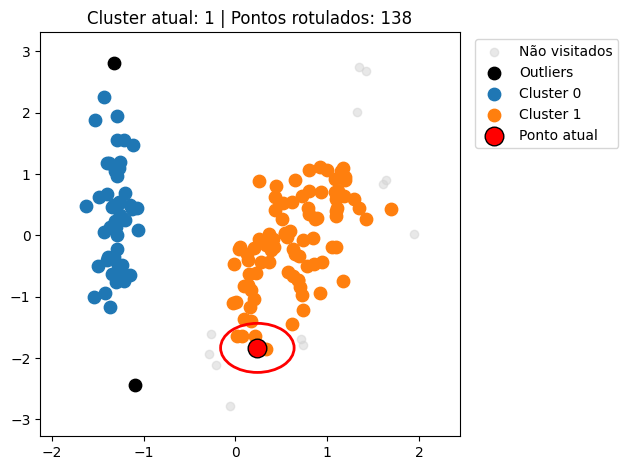

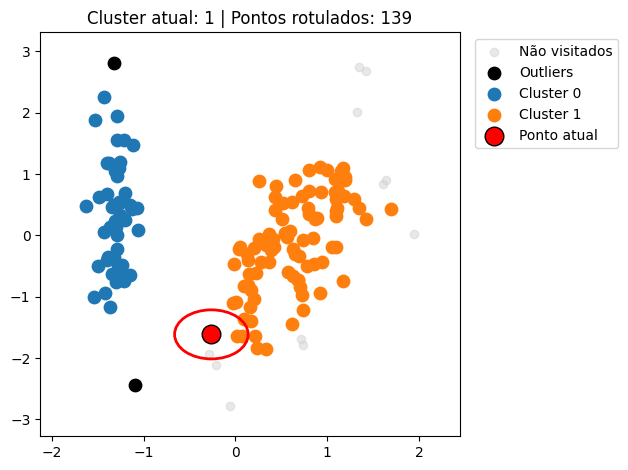

In [11]:
from sklearn.neighbors import NearestNeighbors

X_pca = StandardScaler().fit_transform(X_pca)

# ==========================================
# Parâmetros DBSCAN
# ==========================================

eps = 0.40
min_samples = 5

# ==========================================
# Estrutura de vizinhança
# ==========================================

nbrs = NearestNeighbors(radius=eps)
nbrs.fit(X_pca)

# -99 = não visitado
# -1 = outlier
# >=0 = cluster
labels = np.full(len(X_pca), -99)

cluster_id = 0

# Cores para clusters
colors = plt.cm.tab10(np.linspace(0,1,10))

plt.figure(figsize=(8,6))

# ==========================================
# DBSCAN didático
# ==========================================

for i in range(len(X_pca)):

    if labels[i] != -99:
        continue

    neighbors = nbrs.radius_neighbors(
        [X_pca[i]],
        return_distance=False
    )[0]

    # --------------------------------------
    # Não é core point → outlier
    # --------------------------------------
    if len(neighbors) < min_samples:

        labels[i] = -1

    # --------------------------------------
    # Novo cluster
    # --------------------------------------
    else:

        labels[i] = cluster_id

        seeds = list(neighbors)

        j = 0

        while j < len(seeds):

            point = seeds[j]

            if labels[point] == -1:
                labels[point] = cluster_id

            if labels[point] == -99:

                labels[point] = cluster_id

                point_neighbors = nbrs.radius_neighbors(
                    [X_pca[point]],
                    return_distance=False
                )[0]

                if len(point_neighbors) >= min_samples:

                    for p in point_neighbors:
                        if p not in seeds:
                            seeds.append(p)

            # ==========================
            # Visualização
            # ==========================

            plt.clf()

            # Não visitados
            mask_unvisited = labels == -99

            plt.scatter(
                X_pca[mask_unvisited,0],
                X_pca[mask_unvisited,1],
                c='lightgray',
                alpha=0.5,
                label='Não visitados'
            )

            # Outliers
            mask_noise = labels == -1

            if np.sum(mask_noise) > 0:
                plt.scatter(
                    X_pca[mask_noise,0],
                    X_pca[mask_noise,1],
                    c='black',
                    s=80,
                    label='Outliers'
                )

            # Clusters encontrados
            for c in range(cluster_id + 1):

                mask_cluster = labels == c

                if np.sum(mask_cluster) > 0:

                    plt.scatter(
                        X_pca[mask_cluster,0],
                        X_pca[mask_cluster,1],
                        color=colors[c % 10],
                        s=80,
                        label=f'Cluster {c}'
                    )

            # Ponto atual
            plt.scatter(
                X_pca[point,0],
                X_pca[point,1],
                c='red',
                s=180,
                edgecolor='black',
                label='Ponto atual'
            )

            # Círculo epsilon
            circle = plt.Circle(
                (X_pca[point,0], X_pca[point,1]),
                eps,
                fill=False,
                color='red',
                linewidth=2
            )

            plt.gca().add_patch(circle)

            plt.title(
                f'Cluster atual: {cluster_id} | '
                f'Pontos rotulados: {(labels!=-99).sum()}'
            )

            plt.xlim(
                X_pca[:,0].min()-0.5,
                X_pca[:,0].max()+0.5
            )

            plt.ylim(
                X_pca[:,1].min()-0.5,
                X_pca[:,1].max()+0.5
            )

            plt.legend(
                bbox_to_anchor=(1.02,1),
                loc='upper left'
            )

            plt.tight_layout()

            plt.pause(0.1)

            j += 1

        cluster_id += 1

plt.show()

## Sensibilidade ao Parâmetro eps

In [12]:
for eps in [0.4, 0.6, 0.8, 1.0]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_outliers = list(labels).count(-1)
    print(f'eps={eps:.1f} | Clusters={n_clusters} | Outliers={n_outliers}')

eps=0.4 | Clusters=6 | Outliers=66
eps=0.6 | Clusters=2 | Outliers=26
eps=0.8 | Clusters=2 | Outliers=4
eps=1.0 | Clusters=2 | Outliers=3


# Conclusões

## Vantagens
- Não requer definir K
- Detecta outliers automaticamente
- Funciona com clusters de formatos arbitrários
- Robusto a ruídos

## Limitações
- Sensível aos parâmetros eps e min_samples
- Pode apresentar dificuldades quando os clusters possuem densidades muito diferentes

## Comparação
| Característica | K-Means | K-Medoids | DBSCAN |
|---|---|---|---|
| Define K previamente | Sim | Sim | Não |
| Detecta outliers | Não | Não | Sim |
| Baseado em densidade | Não | Não | Sim |